<a href="https://colab.research.google.com/github/LeoFairley123/EMSC2010-Individual-Project/blob/main/EMSC2010_Individual_Project_U7488277.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Title**

## Project Overview

# Import Libraries and data

##Import Libraries

In [27]:
# Install the Bambi library, a high-level Bayesian modeling library
!pip install bambi

In [28]:
import numpy as np # for working with numerical arrays and mathematical operations
import matplotlib.pyplot as plt # for creating static, animated, and interactive visualizations in Python
import bambi as bmb # for automated Bayesian regression
import arviz as az # for analysis and visualization of Bayesian models
import pandas as pd # for data manipulation and analysis, especially with DataFrames
from scipy import stats # for statistical functions and distributions
import xarray as xr # for working with labeled multi-dimensional arrays

##Import Data

In [29]:
# This cell is responsible for loading various climate-related time-series datasets
# from GitHub repositories into pandas DataFrames and performing initial preprocessing.

# --- Load CO2 concentration data (Mauna Loa) ---
# Source: https://gml.noaa.gov/ccgg/trends/data.html
path_CO2 = "https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/55d8918967db36feb87fb34ae78e4699a9d1a989/co2_mm_gl.csv"
df_CO2 = pd.read_csv(path_CO2, skiprows=38) # Skip header rows
df_CO2['dt'] = pd.to_datetime(df_CO2[['year', 'month']].assign(day=1)) # Create datetime column

# --- Load Global Average Surface Temperature Anomaly data ---
# Source: NASA GISS Surface Temperature Analysis (GISTEMP)
path_Ts = "https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/Global%20avg%20surface%20temperature%20anomaly.csv"
df_Ts = pd.read_csv(path_Ts, skiprows=3) # Skip header rows
df_Ts['Surface Temperature'] = df_Ts['Departure from Average'] + 13.9 # Convert anomaly to absolute temperature
df_Ts['dt'] = pd.to_datetime(df_Ts['Date'], format='%Y%m') # Create datetime column from YYYYMM format

# --- Load Total Solar Irradiance (TSI) data ---
# Source: SORCE/TIM and other composite datasets
path_S = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/tsi-ssi_v03r00_observed-tsi-composite_s19780101_e20250630_c20250917.txt'
df_S = pd.read_csv(path_S, skiprows=76, sep=',', na_values=[-99], names=['time', 'TSI', 'uncertainty'], header=0)
df_S['dt'] = pd.to_datetime(df_S['time']) # Create datetime column
df_S = df_S.dropna(subset=['TSI']) # Remove rows where TSI data is missing

# --- Helper function for ERA5-derived data datetime formatting ---
def format_era5_dt(df):
  # Convert 'valid_time' to monthly period and then to timestamp (start of month)
  df['dt'] = pd.to_datetime(df['valid_time']).dt.to_period('M').dt.to_timestamp()
  return df

# --- (Commented out) Example ERA5 data loading (SST, FAL, various radiative fluxes) ---
# These lines are commented out but show the pattern for loading ERA5 reanalysis data.
# Each dataset would be loaded and then processed with the `format_era5_dt` function.
# path_SST = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/SST.csv'
# df_SST = format_era5_dt(pd.read_csv(path_SST))

path_FAL = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/fal.csv'
df_FAL = format_era5_dt(pd.read_csv(path_FAL))

# path_sdlwrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_sdlwrf.csv'
# df_sdlwrf = format_era5_dt(pd.read_csv(path_sdlwrf))

# path_sdswrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_sdswrf.csv'
# df_sdswrf = format_era5_dt(pd.read_csv(path_sdswrf))

# path_snlwrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_snlwrf.csv'
# df_snlwrf = format_era5_dt(pd.read_csv(path_snlwrf))

# path_snswrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_snswrf.csv'
# df_snswrf = format_era5_dt(pd.read_csv(path_snswrf))

path_tdswrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_tdswrf.csv'
df_tdswrf = format_era5_dt(pd.read_csv(path_tdswrf))

# --- Load ERA5 average total net longwave radiation flux at surface (tnlwrf) ---
path_tnlwrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_tnlwrf.csv'
df_tnlwrf = format_era5_dt(pd.read_csv(path_tnlwrf))

# --- (Commented out) More ERA5 data loading examples ---
path_tnswrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_tnswrf.csv'
df_tnswrf = format_era5_dt(pd.read_csv(path_tnswrf))

# path_vit = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/vit.csv'
# df_vit = format_era5_dt(pd.read_csv(path_vit))

# --- Load Deep Ocean Temperature Anomaly data (2000-6000m depth) ---
# Source: Scripps Institution of Oceanography, Argo program
path_Td2 = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/Temperature2000_6000m_monthly_timeseries.txt'
df_Td2 = pd.read_csv(path_Td2, sep=r'\s+', names=['Year', 'Month', 'Temperature', 'Uncertainty']).dropna(subset=['Temperature'])
df_Td2['dt'] = pd.to_datetime(df_Td2[['Year', 'Month']].assign(Day=1)) # Create datetime column

# --- Load Deep Ocean Temperature Anomaly data (0-2000m depth) ---
# Source: Scripps Institution of Oceanography, Argo program
path_Td1 = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/Temperature0_2000m_monthly_timeseries.txt'
df_Td1 = pd.read_csv(path_Td1, sep=r'\s+', names=['Year', 'Month', 'Temperature', 'Uncertainty']).dropna(subset=['Temperature'])
df_Td1['dt'] = pd.to_datetime(df_Td1[['Year', 'Month']].assign(Day=1)) # Create datetime column

#Constants

##Defined Constants

In [30]:
# --- Physical and Model Constants ---

# Stefan-Boltzmann constant (W m^-2 K^-4)
sigma = 5.67e-8

# Time conversion: number of seconds in a standard year (365 days)
seconds_per_year = 365 * 24 * 3600

# Ocean fraction of the Earth's surface (~71%)
ocean_fraction = 0.71

# Seawater properties
rho_o = 1025     # Density of seawater (kg/m^3)
Cp_sw = 4000     # Specific heat capacity of seawater (J/kg/K)

# --- Deep Ocean Layers ---
h1 = 2000        # Depth of the upper deep ocean layer (m)
h2 = 4000        # Depth of the lower deep ocean layer (m)

# Heat capacities of the deep ocean layers (J m^-2 K^-1)
C_d1 = rho_o * Cp_sw * h1
C_d2 = rho_o * Cp_sw * h2

# --- Surface Layer (Mixed Layer) ---
ho = 50          # Depth of the ocean mixed layer (m)
rho_l = 1000     # Density of land/soil (kg/m^3)
C_l = 800        # Specific heat capacity of land (J/kg/K)
hl = 2           # Effective depth of the land thermal layer (m)

# Weighted average heat capacity for the surface (Ocean + Land) (J m^-2 K^-1)
C_s = ocean_fraction * rho_o * Cp_sw * ho + (1-ocean_fraction) * rho_l * C_l * hl

# --- Albedo Parameters (Ice-Albedo Feedback) ---
ocean_albedo = 0.15
sea_ice_albedo = 0.65
land_albedo = 0.25
snow_albedo = 0.80

# alpha_min: Minimum planetary albedo (weighted average for ice-free Earth) [unitless]
alpha_min = ocean_fraction * ocean_albedo + (1-ocean_fraction) * land_albedo

# alpha_max: Maximum planetary albedo (weighted average for fully glaciated Earth) [unitless]
alpha_max = ocean_fraction * sea_ice_albedo + (1-ocean_fraction) * snow_albedo

##Derived constants

###CO2 growth rate

In [31]:
# CO2(t) = CO2_growth_rate_acceleration*time^2+co2_growth_rate*time+C0

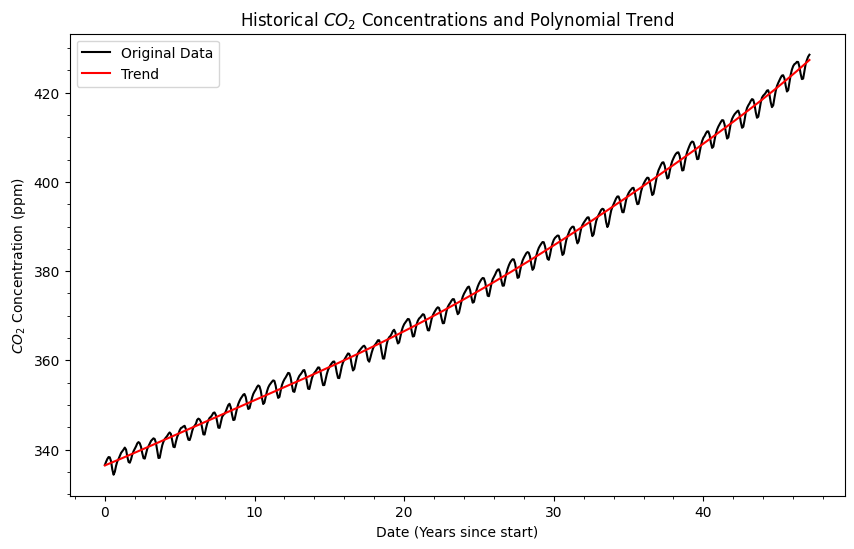

In [32]:
# --- Data Preparation ---
# Convert the 'dt' datetime column into a numerical array representing years since the start of the record
date_co2 = (df_CO2['dt'] - df_CO2['dt'].min()).dt.days / 365.25
date_co2 = date_co2.to_numpy()

# Extract the CO2 concentration values (ppm) as a numpy array
CO2_obs = df_CO2['average'].to_numpy()

# --- Polynomial Trend Fitting ---
# Define the degree of the polynomial to fit the long-term trend
order = 6

# Use np.polyfit to calculate the coefficients (pp) that minimize the squared error
co2_pp = np.polyfit(date_co2, CO2_obs, order)

# Evaluate the resulting polynomial at every time point to generate the trend line
co2_trend = np.polyval(co2_pp, date_co2)

# --- Visualization ---
plt.figure(figsize=(10, 6))
plt.plot(date_co2, CO2_obs, 'k', label='Original Data') # Plot the raw CO2 data in black
plt.plot(date_co2, co2_trend, 'r', label='Trend') # Plot the fitted polynomial trend in red

# Label the axes and improve the aesthetics
plt.title('Historical $CO_2$ Concentrations and Polynomial Trend')
plt.xlabel('Date (Years since start)')
plt.ylabel('$CO_2$ Concentration (ppm)')
plt.minorticks_on()
plt.legend()
plt.show()

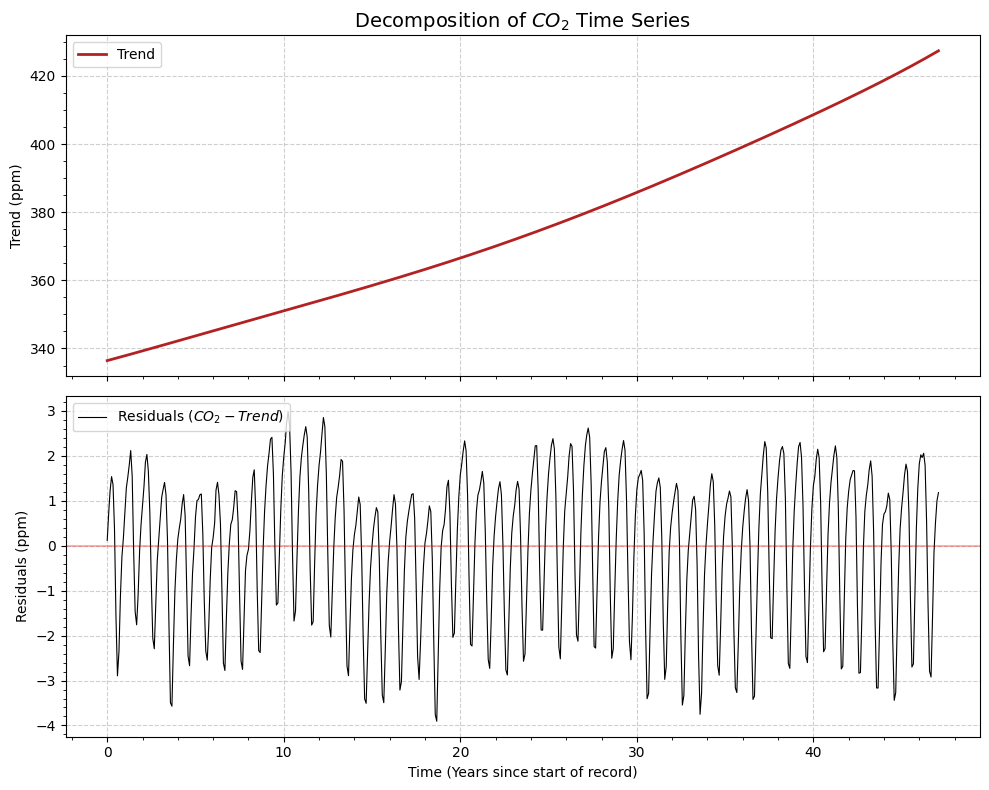

In [33]:
# --- Calculate Residuals ---
# The residuals represent the seasonal cycle and noise left after removing the trend
co2_residuals = CO2_obs - co2_trend

# --- Visualization: Trend and Residuals ---
# Create a figure with two vertical subplots sharing the same x-axis
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top Plot: Long-term Polynomial Trend
axes[0].plot(date_co2, co2_trend, color='firebrick', lw=2, label='Trend')
axes[0].set_ylabel('Trend (ppm)')
axes[0].set_title('Decomposition of $CO_2$ Time Series', fontsize=14)
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].minorticks_on()

# Bottom Plot: Residuals (Seasonal cycle + noise)
axes[1].plot(date_co2, co2_residuals, color='black', lw=0.8, label='Residuals ($CO_2 - Trend$)')
axes[1].axhline(0, color='red', linestyle='-', alpha=0.3) # Add a zero baseline for reference
axes[1].set_ylabel('Residuals (ppm)')
axes[1].set_xlabel('Time (Years since start of record)')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].minorticks_on()

# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

In [34]:
def freq_spectrum(time, signal):
    """
    Calculates the frequency spectrum (amplitude) of a given signal using FFT.
    Handles non-uniform time series by interpolating onto a uniform grid.

    Parameters:
    time (array): Array of time values (e.g., years)
    signal (array): Array of signal values (e.g., CO2 concentration)

    Returns:
    x (array): Uniformly spaced time array used for FFT
    y (array): Signal interpolated onto the uniform grid
    freqs (array): Frequencies corresponding to the FFT values
    fft_vals (array): Complex results of the Real Fast Fourier Transform
    amplitude (array): Scaled peak amplitude for each frequency
    """
    n = len(time)

    # 1. Create a uniformly spaced time grid (required for standard FFT algorithms)
    x = np.linspace(np.min(time), np.max(time), n)

    # 2. Interpolate the original signal onto the uniform time grid
    y = np.interp(x, time, signal)

    # 3. Calculate the sample rate (points per unit of time)
    sample_rate = 1 / (x[1] - x[0])

    # 4. Perform the Real FFT (takes real input, returns positive frequency components)
    fft_vals = np.fft.rfft(y)

    # 5. Generate the frequency bins (cycles per unit of time)
    freqs = np.fft.rfftfreq(n, d=1/sample_rate)

    # 6. Calculate the amplitude: scale by (2/n) so peak height matches the sinusoid amplitude
    amplitude = (2 / n) * np.abs(fft_vals)

    # 7. Correct the DC component (frequency 0) which shouldn't be doubled by the rfft scale factor
    amplitude[0] /= 2

    return freqs, amplitude, fft_vals

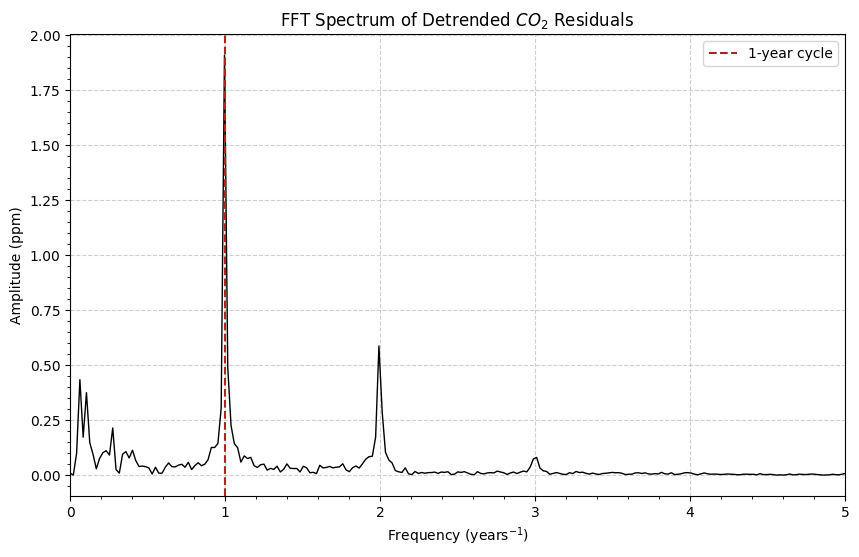

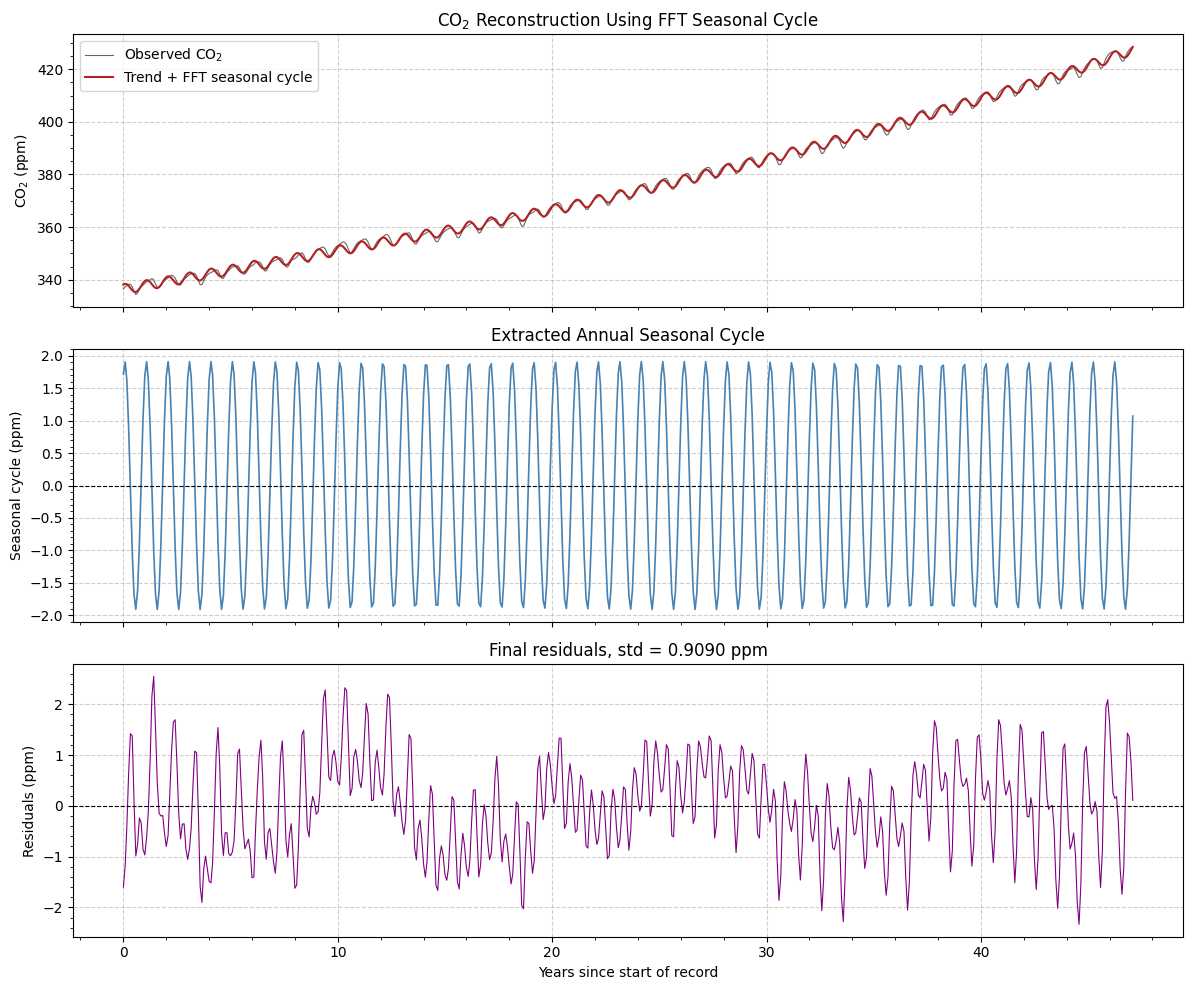

Seasonal CO2 expression from FFT:
CO2_seasonal(t) = 1.9096 * cos(2π * 0.9964 * t + -0.4540)

Full reconstructed CO2 expression:
CO2(t) = polynomial_trend(t) + 1.9096 * cos(2π * 0.9964 * t + -0.4540)


In [35]:
# --- Perform Spectral Analysis ---
# Calculate the frequency, phase, and amplitude of the detrended CO2 residuals using FFT
freqs_co2, amps_co2, fft_vals_co2 = freq_spectrum(date_co2, co2_residuals)

# --- Visualize the Frequency Spectrum ---
plt.figure(figsize=(10, 6))
plt.plot(freqs_co2, amps_co2, color='black', lw=1)

# Add a reference line for the 1-year (seasonal) cycle
plt.axvline(1, color='firebrick', linestyle='--', label='1-year cycle')
plt.xlabel('Frequency (years$^{-1}$)')
plt.ylabel('Amplitude (ppm)')
plt.title('FFT Spectrum of Detrended $CO_2$ Residuals')
plt.xlim(0, 5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.minorticks_on()
plt.legend()
plt.show()

# --- Extract the Annual Cycle Components ---
# Find the index of the frequency bin closest to exactly 1.0 cycles/year
idx_annual = np.argmin(np.abs(freqs_co2 - 1.0))

# Extract the amplitude and phase angle (in radians) for the seasonal component
A_annual = amps_co2[idx_annual]
phi_annual = np.angle(fft_vals_co2[idx_annual])

# --- Reconstruct the Seasonal and Full Signals ---
# Create the seasonal cycle signal using the extracted amplitude and phase
co2_seasonal_fft = A_annual * np.cos(2 * np.pi * freqs_co2[idx_annual] * date_co2 + phi_annual)

# Combine the long-term polynomial trend with the new FFT-derived seasonal cycle
co2_reconstructed_fft = co2_trend + co2_seasonal_fft

# Calculate the remaining residuals (noise) after the full reconstruction
co2_final_residuals_fft = CO2_obs - co2_reconstructed_fft

# --- Visualize the Reconstruction Results ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Subplot A: Total CO2 Reconstruction vs Observations
axes[0].plot(date_co2, CO2_obs, color='black', lw=0.8, alpha=0.6, label='Observed CO$_2$')
axes[0].plot(date_co2, co2_reconstructed_fft, color='firebrick', lw=1.5, label='Trend + FFT seasonal cycle')
axes[0].set_ylabel('CO$_2$ (ppm)')
axes[0].set_title('CO$_2$ Reconstruction Using FFT Seasonal Cycle')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].minorticks_on()

# Subplot B: The isolated annual cycle component
axes[1].plot(date_co2, co2_seasonal_fft, color='steelblue', lw=1.2)
axes[1].axhline(0, color='black', linestyle='--', lw=0.8)
axes[1].set_ylabel('Seasonal cycle (ppm)')
axes[1].set_title('Extracted Annual Seasonal Cycle')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].minorticks_on()

# Subplot C: Final residuals (ideally white noise centered at zero)
axes[2].plot(date_co2, co2_final_residuals_fft, color='purple', lw=0.8)
axes[2].axhline(0, color='black', linestyle='--', lw=0.8)
axes[2].set_ylabel('Residuals (ppm)')
axes[2].set_xlabel('Years since start of record')
axes[2].set_title(f'Final residuals, std = {co2_final_residuals_fft.std():.4f} ppm')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].minorticks_on()

plt.tight_layout()
plt.show()

# --- Summary Output ---
# Print the mathematical expressions derived from the analysis
print("Seasonal CO2 expression from FFT:")
print(
    f"CO2_seasonal(t) = {A_annual:.4f} * cos("
    f"2π * {freqs_co2[idx_annual]:.4f} * t + {phi_annual:.4f})"
)

print("\nFull reconstructed CO2 expression:")
print(
    "CO2(t) = polynomial_trend(t) "
    f"+ {A_annual:.4f} * cos(2π * {freqs_co2[idx_annual]:.4f} * t + {phi_annual:.4f})"
)

In [36]:
def CO2_growth_rate(t):
    """
    Calculates the CO2 concentration at time t by combining a long-term
    anthropogenic trend (polynomial) with a seasonal cycle (FFT-derived).

    Parameters:
    t (float or ndarray): Time in years since the start of the record.

    Returns:
    rate (float or ndarray): CO2 concentration in ppm.
    """
    # 1. Evaluate the polynomial trend at time t
    trend = np.polyval(co2_pp, t)

    # 2. Add the seasonal cycle using the amplitude (A_annual) and phase (phi_annual)
    # derived from the Fast Fourier Transform analysis.
    # The frequency is taken from the peak in the power spectrum (~1 year^-1).
    freq = freqs_co2[idx_annual]
    seasonal_cycle = A_annual * np.cos(2 * np.pi * freq * t + phi_annual)

    return trend + seasonal_cycle

In [37]:
#ΔF=OLR2−OLR1 ​=α⋅ln(C0/​CO2​​)

###Atmospheric Heat Capacity

In [38]:
# Calculate Heat Capacities for Atmospheric Layers
# Formula: Heat Capacity Atmosphere = (Specific heat capacity of dry air * pressure thickness of atmosphere) / gravity

# Specific heat capacity of dry air at constant pressure (J/kg/K)
Cp = 1004

# Pressure thickness of the upper atmospheric layer (Pa)
delta_p1 = 30000

# Pressure thickness of the lower atmospheric layer (Pa)
delta_p2 = 70000

# Acceleration due to gravity (m/s^2)
g = 9.81

# Calculate heat capacity for layer 1 (J/m^2 K)
Ca1 = (Cp * delta_p1) / g

# Calculate heat capacity for layer 2 (J/m^2 K)
Ca2 = (Cp * delta_p2) / g

# Display the calculated heat capacities
print(f"Ca1 = {Ca1:.4f} J/m^2 K")
print(f"Ca2 = {Ca2:.4f} J/m^2 K")

Ca1 = 3070336.3914 J/m^2 K
Ca2 = 7164118.2467 J/m^2 K


In [39]:
#Ca = Cp/g * integral dp (J/K*m^2) or Ca = integral of ro *cp*dz
#where ro(z) = atm density, cp = specific heat capacity of air, dz = vertical layer thickness
# cp = J/kg*K
# VIT = (K * kg/m^2)
# VIT/Ta = (kg/m^2) -> * Cp = (J/K*m^2)

#dp = -rogdz -> Ca = Cp/g * integral dp -> Ca = (Cp*delta p)/g
#Ca = F_atm_net/(dT/dt)

###Solar Insolation via FFT

In [40]:
def lowpass_filter(time, signal, cutoff):
    """
    Removes high-frequency noise from a signal using a Fast Fourier Transform (FFT).

    Parameters:
    time (array): Time values (e.g., years).
    signal (array): The data values to be filtered.
    cutoff (float): Frequency threshold (cycles/unit time). Components above this are removed.

    Returns:
    x (array): Uniform time grid.
    filtered_signal (array): The reconstructed low-frequency signal.
    """
    n = len(time)

    # 1. Create a uniform time grid (required for FFT) and interpolate the signal
    x = np.linspace(np.min(time), np.max(time), n)
    y = np.interp(x, time, signal)

    # 2. Perform Real FFT and calculate frequency bins
    sample_rate = 1 / (x[1] - x[0])
    fft_vals = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1/sample_rate)

    # 3. Filter: Set amplitudes to zero for all frequencies above the cutoff
    fft_vals[freqs > cutoff] = 0.0

    # 4. Reconstruct the signal using the Inverse FFT
    filtered_signal = np.fft.irfft(fft_vals, n=len(time))

    return x, filtered_signal


def highpass_filter(time, signal, cutoff):
    """
    Removes low-frequency trends or cycles from a signal.

    Parameters:
    time (array): Time values.
    signal (array): Data values.
    cutoff (list/tuple): Threshold for filtering; specifically uses cutoff[1].

    Returns:
    x (array): Uniform time grid.
    filtered_signal (array): The reconstructed high-frequency signal.
    """
    n = len(time)

    # 1. Interpolate onto uniform grid
    x = np.linspace(np.min(time), np.max(time), n)
    y = np.interp(x, time, signal)

    # 2. Perform FFT
    sample_rate = 1 / (x[1] - x[0])
    fft_vals = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1/sample_rate)

    # 3. Filter: Set amplitudes to zero for frequencies below the specified threshold.
    # This isolates the fast-varying components of the signal.
    fft_vals[freqs < cutoff[1]] = 0.0

    # 4. Reconstruct
    filtered_signal = np.fft.irfft(fft_vals, n=len(time))

    return x, filtered_signal


def bandpass_filter(time, signal, cutoff_range):
    """
    Isolates a specific frequency band (e.g., the 11-year solar cycle).

    Parameters:
    time (array): Time values.
    signal (array): Data values.
    cutoff_range (list): A [low, high] frequency range to keep.

    Returns:
    x (array): Uniform time grid.
    filtered_signal (array): Reconstructed signal containing only frequencies in range.
    """
    n = len(time)

    # 1. Interpolate onto uniform grid
    x = np.linspace(np.min(time), np.max(time), n)
    y = np.interp(x, time, signal)

    # 2. Perform FFT
    sample_rate = 1 / (x[1] - x[0])
    fft_vals = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1/sample_rate)

    # 3. Filter: Zero out frequencies outside the [low, high] range
    fft_vals[(freqs < cutoff_range[0]) | (freqs > cutoff_range[1])] = 0.0

    # 4. Reconstruct filtered signal using Inverse FFT
    filtered_signal = np.fft.irfft(fft_vals, n=len(time))
    return x, filtered_signal

In [41]:
# Extract the Total Solar Irradiance (TSI) values as a numpy array for numerical analysis
TSI = df_S['TSI'].values

# Create a time array ('age') representing years.
# np.arange(1, len(TSI) + 1) creates a sequence of days, which is then divided by 365.25.
age_TSI = np.arange(1, len(TSI) + 1) / 365.25

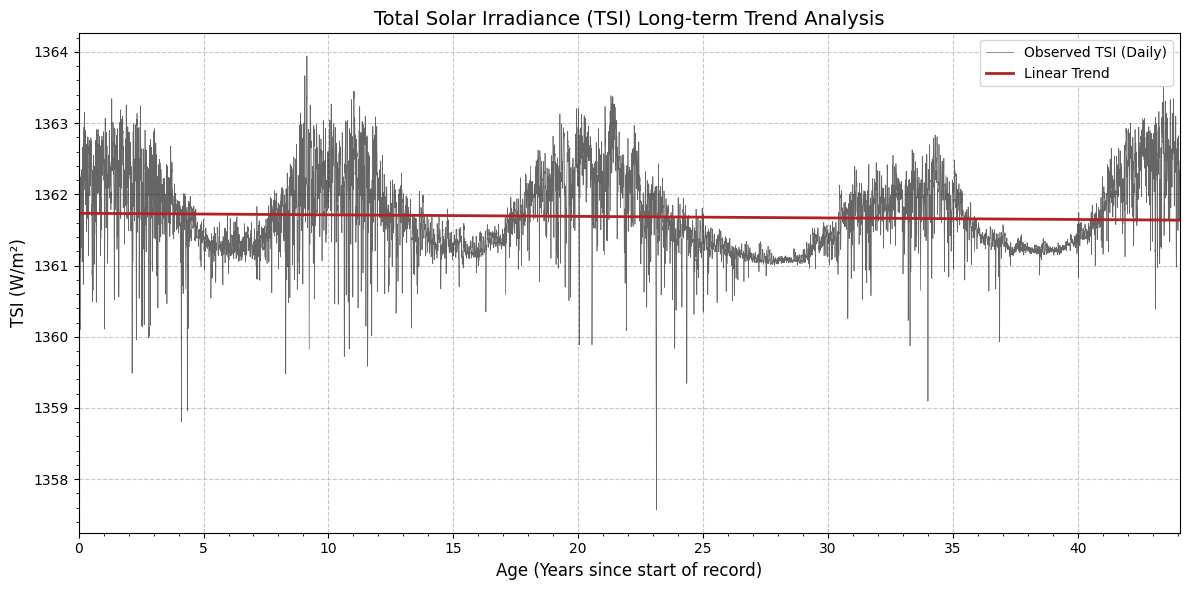

In [42]:
# Calculate a first-degree polynomial (linear) fit to identify the long-term trend
pp_TSI = np.polyfit(age_TSI, TSI, 1)

plt.figure(figsize=(12, 6))

# Plot raw TSI and the linear trend
plt.plot(age_TSI, TSI, color='black', lw=0.5, alpha=0.6, label='Observed TSI (Daily)')
plt.plot(age_TSI, np.polyval(pp_TSI, age_TSI), color='firebrick', lw=2, label='Linear Trend')
plt.title('Total Solar Irradiance (TSI) Long-term Trend Analysis', fontsize=14)
plt.xlabel('Age (Years since start of record)', fontsize=12)
plt.ylabel('TSI (W/m²)', fontsize=12)
plt.xlim([0, age_TSI.max()])
plt.grid(True, linestyle='--', alpha=0.7)
plt.minorticks_on()
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

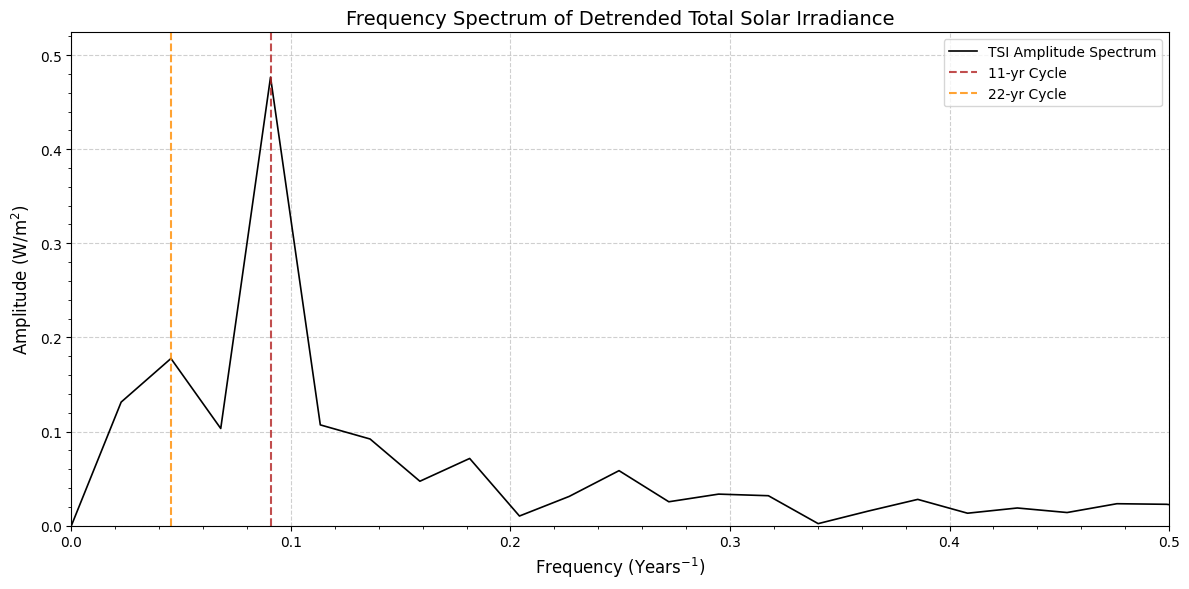

In [43]:
# --- Spectral Analysis of Detrended TSI ---
# Calculate the detrended data by subtracting the linear trend from the observations
detrend = TSI - np.polyval(pp_TSI, age_TSI)

# Compute the frequency spectrum (frequency and amplitude) using FFT
freqs, amps, fft_vals = freq_spectrum(age_TSI, detrend)

# --- Visualization Setup ---
plt.figure(figsize=(12, 6))
plt.plot(freqs, amps, color='black', lw=1.2, label='TSI Amplitude Spectrum')
plt.axvline(x=1/11, color='firebrick', ls='--', alpha=0.8, label='11-yr Cycle')
plt.axvline(x=1/22, color='darkorange', ls='--', alpha=0.8, label='22-yr Cycle')
plt.title('Frequency Spectrum of Detrended Total Solar Irradiance', fontsize=14)
plt.xlabel('Frequency (Years$^{-1}$)', fontsize=12)
plt.ylabel('Amplitude (W/m$^2$)', fontsize=12)
plt.xlim([0, 0.5])
plt.ylim([0, max(amps) * 1.1])
plt.grid(True, linestyle='--', alpha=0.6)
plt.minorticks_on()
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

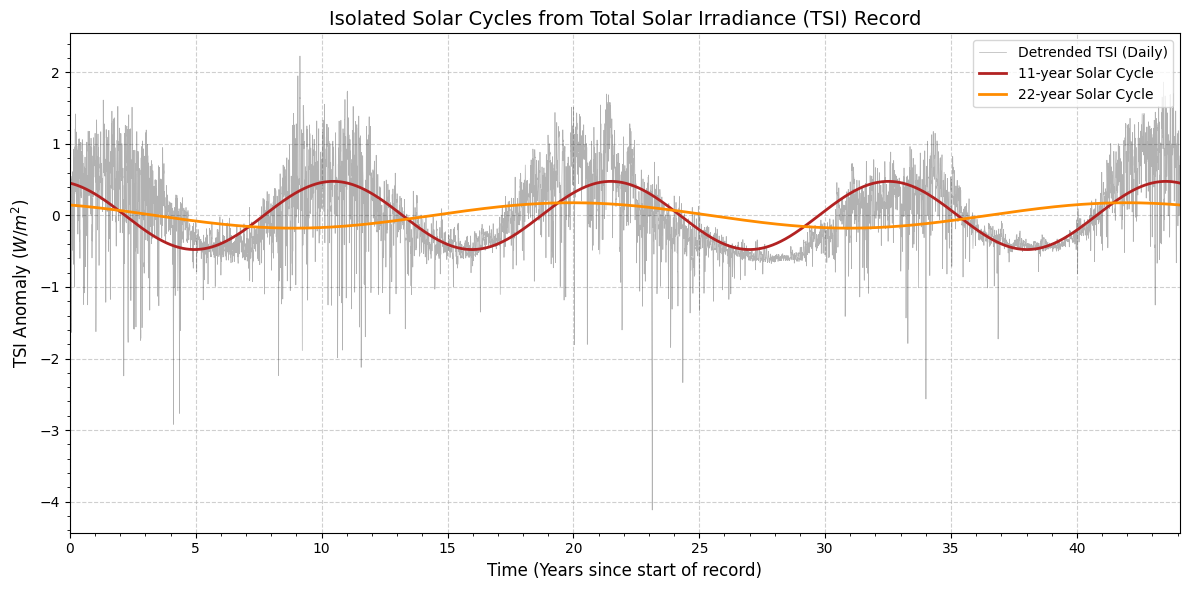

In [44]:
# --- Solar Cycle Isolation (11-yr and 22-yr) ---
# Define the frequency bands for isolation
# 11-year cycle corresponds to ~0.09 years^-1
# 22-year cycle corresponds to ~0.045 years^-1
x11, y11 = bandpass_filter(age_TSI, detrend, [0.08, 0.10])
x22, y22 = bandpass_filter(age_TSI, detrend, [0.03, 0.06])

# --- Visualization of Filtered TSI Anomalies ---
plt.figure(figsize=(12, 6))

# Plot the underlying detrended daily TSI data
plt.plot(age_TSI, detrend, color='black', alpha=0.3, lw=0.5, label='Detrended TSI (Daily)')

# Plot isolated cycles
plt.plot(x11, y11, color='firebrick', lw=2, label='11-year Solar Cycle')
plt.plot(x22, y22, color='darkorange', lw=2, label='22-year Solar Cycle')
plt.title('Isolated Solar Cycles from Total Solar Irradiance (TSI) Record', fontsize=14)
plt.xlabel('Time (Years since start of record)', fontsize=12)
plt.ylabel('TSI Anomaly ($W/m^2$)', fontsize=12)
plt.xlim([0, age_TSI.max()])
plt.grid(True, linestyle='--', alpha=0.6)
plt.minorticks_on()
plt.legend(frameon=True, loc='upper right')

plt.tight_layout()
plt.show()

In [45]:
   # S = S0 + A_cycle1 * np.sin(2 * np.pi * t / P_cycle1) + A_cycle2 * np.sin(2 * np.pi * t / P_cycle2)

In [46]:
# --- Calculate Baseline TSI and Amplitudes ---
S0 = df_S['TSI'].mean()
f11 = np.argmin(np.abs(freqs - 1/11))
f22 = np.argmin(np.abs(freqs - 1/22))
A11 = amps[f11]
A22 = amps[f22]

# --- Spectral Analysis (RFFT) ---
# Perform a Real Fast Fourier Transform (RFFT) on the interpolated detrended TSI data
fft_vals = np.fft.rfft(detrend)
# Calculate the frequencies corresponding to the FFT results
all_freqs = np.fft.rfftfreq(len(age_TSI), d=(age_TSI[1]-age_TSI[0]))

# --- Phase Extraction ---
# Extract the phase angle (in radians) for the 11-year and 22-year cycles
phi11 = np.angle(fft_vals[f11])
phi22 = np.angle(fft_vals[f22])

In [47]:
def Solar_Insolation(t):
    """
    Calculates the Total Solar Irradiance (TSI) at time t by reconstructing
    the 11-year and 22-year solar cycles derived from spectral analysis.

    Parameters:
    t (float or ndarray): Time in years.

    Returns:
    S (float or ndarray): Reconstructed TSI (W/m^2).
    """
    # Reconstruct the 11-year Schwabe cycle using extracted amplitude and phase
    cycle11 = A11 * np.cos(2*np.pi*t/11 + phi11)

    # Reconstruct the 22-year Hale cycle using extracted amplitude and phase
    cycle22 = A22 * np.cos(2*np.pi*t/22 + phi22)

    # Return the sum of the baseline irradiance (S0) and the two primary cycles
    return S0 + cycle11 + cycle22

Baseline S0  = 1361.6862 W/m²
Amplitude 11 = 0.4765 W/m²
Phase 11     = 0.3221 rad
Amplitude 22 = 0.1776 W/m²
Phase 22     = 0.6044 rad


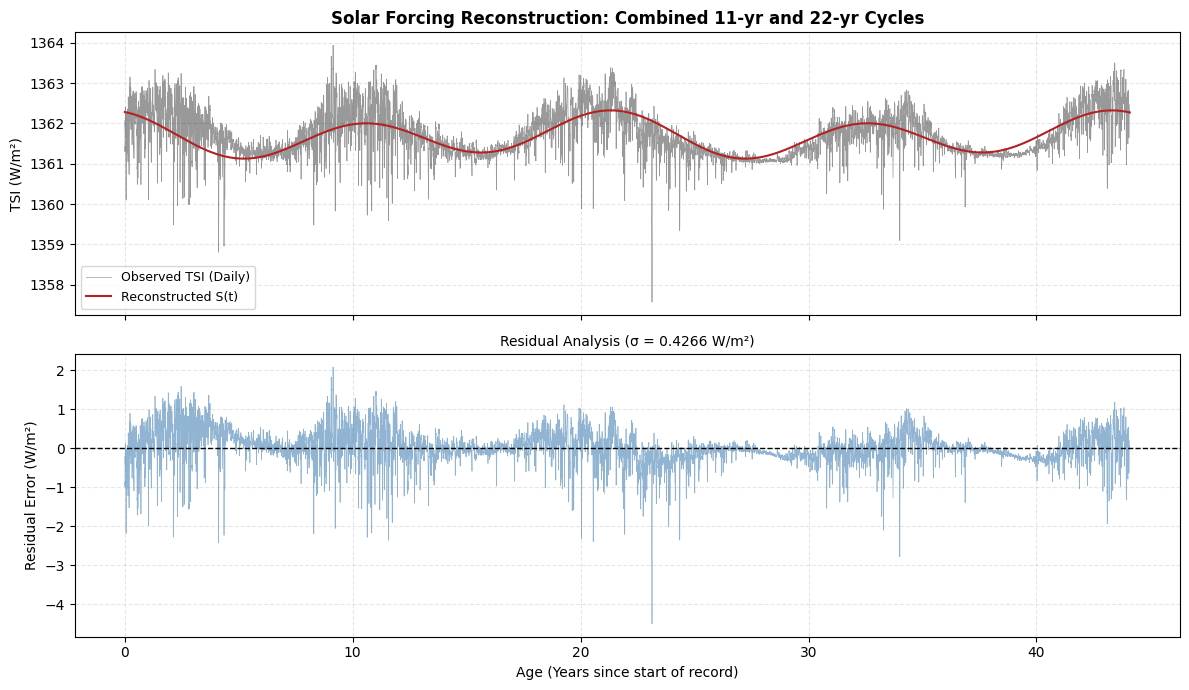

In [48]:
# --- Calculate Reconstructed Solar Forcing and Residuals ---
# Evaluate the solar insolation function over the time period
S = Solar_Insolation(age_TSI)
residuals = TSI - S

# --- Display Reconstructed Parameters ---
print(f"Baseline S0  = {S0:.4f} W/m²")
print(f"Amplitude 11 = {A11:.4f} W/m²")
print(f"Phase 11     = {phi11:.4f} rad")
print(f"Amplitude 22 = {A22:.4f} W/m²")
print(f"Phase 22     = {phi22:.4f} rad")

# --- Visualization: Solar Fit and Residual Analysis ---
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top Plot: Observed vs. Reconstructed Solar Forcing
axes[0].plot(age_TSI, TSI, color='black', lw=0.5, alpha=0.4, label='Observed TSI (Daily)')
axes[0].plot(age_TSI, S, color='firebrick', lw=1.5, label='Reconstructed S(t)')
axes[0].set_ylabel('TSI (W/m²)')
axes[0].set_title('Solar Forcing Reconstruction: Combined 11-yr and 22-yr Cycles', fontweight='bold')
axes[0].legend(fontsize=9, frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.3)

# Bottom Plot: Residual Error
axes[1].plot(age_TSI, residuals, color='steelblue', lw=0.5, alpha=0.6)
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].set_ylabel('Residual Error (W/m²)')
axes[1].set_xlabel('Age (Years since start of record)')
axes[1].set_title(f'Residual Analysis (σ = {residuals.std():.4f} W/m²)', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

###Epsilon analytical and numerical (regression)

In [49]:
# --- Calculate Atmospheric Emissivity (Epsilon) ---
# The relationship between Surface Temperature (Ts) and Outgoing Longwave Radiation (OLR)
# is defined by: OLR = sigma * Ts^4 * (1 - epsilon/2)
# Rearranging to solve for epsilon: epsilon = 2 * (1 - OLR / (sigma * Ts^4))

# Ensure OLR values are positive for physical consistency
OLR_abs = np.abs(df_tnlwrf['avg_tnlwrf'])

# --- Derived Time Series for Epsilon ---
# Calculate epsilon at each time step using absolute surface temperature (Kelvin)
epsilon_ts = 2 * (1 - OLR_abs / (sigma * (df_Ts['Surface Temperature'] + 273.15)**4))

# --- Statistical Summary ---
# Compute the mean and standard deviation of the emissivity time series
epsilon = epsilon_ts.mean()
epsilon_std = epsilon_ts.std()

print(f"Calculated Emissivity (ε) = {epsilon:.4f} ± {epsilon_std:.4f}")

Calculated Emissivity (ε) = 0.8208 ± 0.0130


In [50]:
# --- Data Alignment and Radiative Flux Preparation ---

# Align OLR (from df_tnlwrf) and Surface Temperature (from df_Ts) datasets
# on the common 'dt' (datetime) column to ensure physical consistency at each time step.
# We drop any rows (NaNs) where data is not available in both sets.
df_aligned = pd.merge(
    df_tnlwrf[['dt', 'avg_tnlwrf']],
    df_Ts[['dt', 'Surface Temperature']],
    on='dt'
).dropna()

# --- Variable Extraction ---

# Extract the absolute value of the net longwave radiation flux (OLR)
OLR = np.abs(df_aligned['avg_tnlwrf'])

# Calculate the total blackbody radiation emitted by the surface (sigma * Ts^4)
# Note: Surface Temperature is converted from Celsius to Kelvin by adding 273.15
radiated = sigma * (df_aligned['Surface Temperature'] + 273.15)**4

In [51]:
# epsilon = 2 * (1 - OLR / (sigma * Ts^4))
# Rearranging to solve with regression: radiated-OLR = (epsilon/2)*radiated

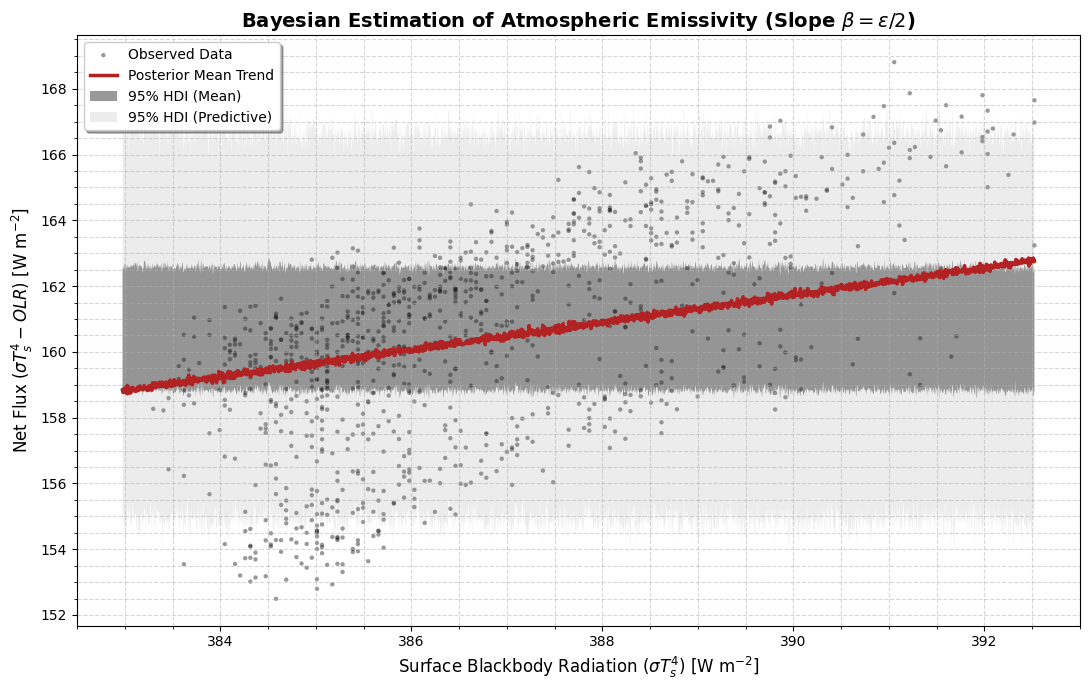

In [52]:
# --- Bayesian Regression for Atmospheric Emissivity ---

# Create a DataFrame for modeling:
# 'y' is the net flux (Radiated - OLR), 'x' is the surface blackbody radiation
data = pd.DataFrame({"y": radiated - OLR, "x": radiated})

# --- Model Definition and Fitting ---
# Define a Bayesian linear model passing through the origin (y ~ 0 + x)
model_linear = bmb.Model("y ~ 0+x", data)
idata_linear = model_linear.fit(progressbar=False)

# --- Posterior Predictions ---
# Generate a dense range of x-values for smooth plotting
x_range = np.linspace(data['x'].min(), data['x'].max(), 2000)
new_data = pd.DataFrame({"x": x_range})

# Generate predictions for the mean (response_params) and the full posterior predictive distribution (response)
model_linear.predict(idata_linear, data=new_data, kind='response_params')
model_linear.predict(idata_linear, data=new_data, kind='response')

# --- Draw and Reshape Posterior Samples ---
y_mean_draws = idata_linear.posterior["mu"].values.reshape(-1, len(x_range))
y_pps_draws = idata_linear.posterior_predictive["y"].values.reshape(-1, len(x_range))

# --- Statistical Uncertainty Calculations ---
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(y_mean_draws, prob=0.95)
hdi_pps = az.hdi(y_pps_draws, prob=0.95)

# --- Visualization ---
plt.figure(figsize=(11, 7))

# Plot observed data points with reduced alpha for density visualization
plt.scatter(data['x'], data['y'], color='black', s=10, alpha=0.4, label="Observed Data", edgecolors='none')

# Plot the central posterior mean trend
plt.plot(x_range, posterior_mean, color="firebrick", lw=2.5, label="Posterior Mean Trend")

# Shade the 95% HDI for the mean (uncertainty in the slope)
plt.fill_between(
    x_range,
    hdi_mean[:, 0],
    hdi_mean[:, 1],
    alpha=0.4,
    color="black",
    label="95% HDI (Mean)",
    edgecolor=None
)

# Shade the 95% HDI for the predictive distribution (expected range of new data)
plt.fill_between(
    x_range,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.15,
    color="gray",
    label="95% HDI (Predictive)",
    edgecolor=None
)

# Formatting labels and appearance
plt.xlabel(r'Surface Blackbody Radiation ($\sigma T_s^4$) [W m$^{-2}$]', fontsize=12)
plt.ylabel(r'Net Flux ($\sigma T_s^4 - OLR$) [W m$^{-2}$]', fontsize=12)
plt.title(r'Bayesian Estimation of Atmospheric Emissivity (Slope $\beta = \epsilon/2$)', fontsize=14, fontweight='bold')

plt.legend(loc='upper left', frameon=True, shadow=True)
plt.minorticks_on()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [53]:
# --- Post-Processing: Atmospheric Emissivity (epsilon) Derivation ---

# Extract the posterior samples for the slope 'x' from the inference data object
# In our model (y ~ 0 + x), the slope beta represents epsilon/2
beta = idata_linear.posterior["x"].values.flatten()

# Convert the slope samples back into emissivity (epsilon) samples
# Since beta = epsilon / 2, then epsilon = 2 * beta
epsilon_samples = 2 * beta

# Calculate the central estimate (mean) of the emissivity from the posterior distribution
epsilon_mean = epsilon_samples.mean()

# Compute the 95% Highest Density Interval (HDI)
# This provides the range within which the true value of epsilon lies with 95% probability
epsilon_hdi = az.hdi(epsilon_samples, prob=0.95)

# Output the results for integration into the Energy Balance Model (EBM)
print(f"Calculated Emissivity (epsilon) = {epsilon_mean:.4f}")
print(f"95% HDI: [{epsilon_hdi[0]:.4f}, {epsilon_hdi[1]:.4f}]")

Calculated Emissivity (epsilon) = 0.8294
95% HDI: [0.8285, 0.8302]


###Gamma1 and Gamma2 analytical and numerical (regression)

In [54]:
# --- Heat Exchange Coefficient (Gamma) Derivations ---

# Gamma1 (Surface-to-Deep Ocean exchange):
# Derived from the energy balance of the first deep ocean layer (0-2000m):
# C_d1(dTd1/dt) = gamma1(Ts - Td1) - gamma2(Td1 - Td2)
# Rearranging for gamma1:
# gamma1 = [C_d1(dTd1/dt) + gamma2(Td1 - Td2)] / (Ts - Td1)

# Gamma2 (Deep-to-Abyssal Ocean exchange):
# Derived from the energy balance of the second deep ocean layer (2000-6000m):
# C_d2(dTd2/dt) = gamma2(Td1 - Td2)
# Rearranging for gamma2:
# gamma2 = [C_d2(dTd2/dt)] / (Td1 - Td2)

# --- Reference Temperatures (Baseline Climatology) ---
# These constants convert temperature anomalies into absolute Kelvin (K)
# Td1_ref: Approximate 1981-2010 mean temperature for the 0-2000m ocean layer
Td1_ref = 275.0

# Td2_ref: Approximate 1981-2010 mean temperature for the 2000-6000m ocean layer
Td2_ref = 274.5

In [55]:
# --- Absolute Temperature Conversion Constants ---
# Td1_ref: Approximate 1981-2010 mean absolute temperature for the 0-2000m layer (K)
# Td2_ref: Approximate 1981-2010 mean absolute temperature for the 2000-6000m layer (K)
Td1_ref = 275.0
Td2_ref = 274.5

# --- Data Alignment ---
# Align the surface temperature record with the upper deep ocean (Td1) record
df_aligned = pd.merge(
    df_Ts[['dt', 'Surface Temperature']],
    df_Td1[['dt', 'Temperature']],
    on='dt'
)

# Further align with the abyssal ocean (Td2) record
# Suffixes are added to distinguish the 'Temperature' columns from different depths
df_aligned = pd.merge(
    df_aligned,
    df_Td2[['dt', 'Temperature']],
    on='dt',
    suffixes=('_Td1', '_Td2')
).dropna()

# --- Unit Conversion ---
# Ts: Convert surface temperature from Celsius to absolute Kelvin
Ts = df_aligned['Surface Temperature'] + 273.15

# Td1/Td2: Add reference climatologies to the anomalies to get absolute Kelvin
Td1 = df_aligned['Temperature_Td1'] + Td1_ref
Td2 = df_aligned['Temperature_Td2'] + Td2_ref

In [56]:
# --- Temperature Gradient Calculation ---
# Calculate derivatives (dT/dt) in Kelvin per second.
# We use the central difference method (np.gradient) for the monthly time-series.
dTd2_dt = np.gradient(Td2, seconds_per_year / 12)
dTd1_dt = np.gradient(Td1, seconds_per_year / 12)

# --- Gamma 2 (Deep Ocean Exchange) Derivation ---
# Based on the energy balance for the abyssal layer (h2):
# C_d2 * (dTd2/dt) = gamma2 * (Td1 - Td2)
# We rearrange to solve for the mean coefficient gamma2 (W/m^2/K).
gamma2_series = (C_d2 * dTd2_dt) / (Td1 - Td2)
gamma2_final = gamma2_series.mean()

# --- Gamma 1 (Surface-to-Deep Exchange) Derivation ---
# Based on the energy balance for the upper deep ocean layer (h1):
# C_d1 * (dTd1/dt) = gamma1 * (Ts - Td1) - gamma2 * (Td1 - Td2)
# Rearranging to isolate gamma1:
gamma1_series = (C_d1 * dTd1_dt + gamma2_final * (Td1 - Td2)) / (Ts - Td1)
gamma1_final = gamma1_series.mean()

# --- Results Summary ---
print(f"Analytical gamma2: {gamma2_final:.4f} W/m^2/K")
print(f"Analytical gamma1: {gamma1_final:.4f} W/m^2/K")

Analytical gamma2: 0.5100 W/m^2/K
Analytical gamma1: 0.1036 W/m^2/K


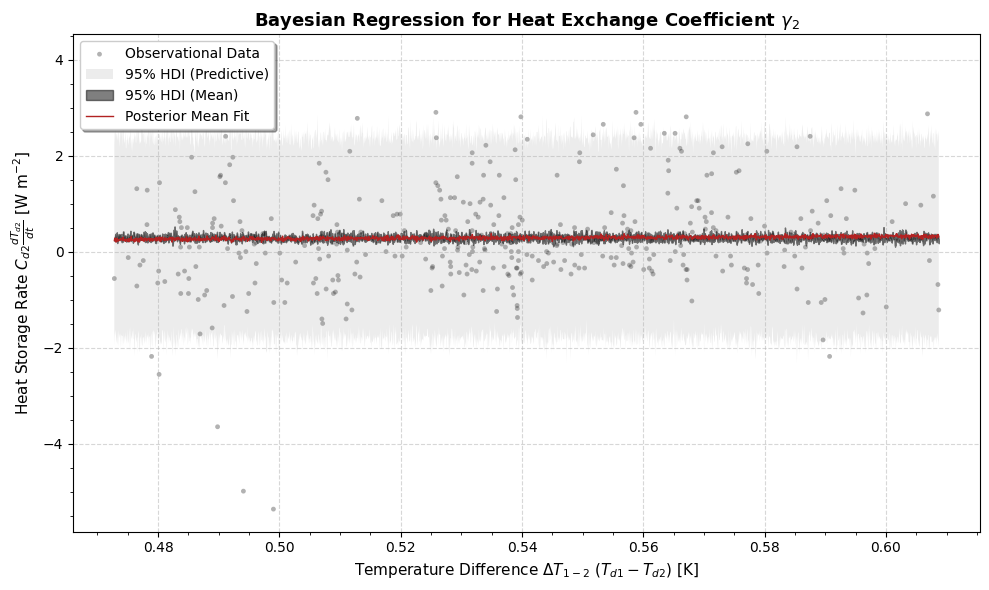

In [57]:
# --- Bayesian Regression for Gamma 2 (Deep-to-Abyssal Exchange) ---

# 1. Prepare data: y is the heat storage rate of the abyssal layer, x is the temp gradient
data = pd.DataFrame({"y": C_d2 * np.gradient(Td2, seconds_per_year/12), "x": Td1 - Td2})

# 2. Fit Bayesian linear model through the origin
# The slope of this line represents the heat exchange coefficient gamma2 (W/m^2/K)
model_linear = bmb.Model("y ~ 0 + x", data)
idata_linear = model_linear.fit(progressbar=False)

# 3. Generate predictions for visualization
x_range = np.linspace(data['x'].min(), data['x'].max(), 2000)
new_data = pd.DataFrame({"x": x_range})

# Predict mean (response_params) and full distribution (response)
model_linear.predict(idata_linear, data=new_data, kind='response_params')
model_linear.predict(idata_linear, data=new_data, kind='response')

# 4. Extract posterior draws and reshape
y_mean_draws = idata_linear.posterior["mu"].values.reshape(-1, len(x_range))
y_pps_draws = idata_linear.posterior_predictive["y"].values.reshape(-1, len(x_range))

# 5. Compute summary statistics (Mean and 95% HDI)
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(y_mean_draws, prob=0.95)
hdi_pps = az.hdi(y_pps_draws, prob=0.95)

# 6. Aesthetic Visualization
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(data['x'], data['y'], color='black', s=12, alpha=0.3, label="Observational Data", edgecolors='none', zorder=1)

# --- Plot uncertainty bands (HDI) ---
# Plot Predictive HDI
plt.fill_between(
    x_range,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.15,
    color="gray",
    label="95% HDI (Predictive)",
    edgecolor=None,
)

# Plot Mean HDI
plt.fill_between(
    x_range,
    hdi_mean[:, 0],
    hdi_mean[:, 1],
    alpha=0.5,
    color="black",
    label="95% HDI (Mean)",
)

# Plot posterior mean line
plt.plot(x_range, posterior_mean, color="firebrick", lw=1, label="Posterior Mean Fit")

# Formatting
plt.xlabel(r'Temperature Difference $\Delta T_{1-2}$ ($T_{d1} - T_{d2}$) [K]', fontsize=11)
plt.ylabel(r'Heat Storage Rate $C_{d2} \frac{dT_{d2}}{dt}$ [W m$^{-2}$]', fontsize=11)
plt.title(r'Bayesian Regression for Heat Exchange Coefficient $\gamma_2$', fontsize=13, fontweight='bold')

plt.legend(frameon=True, shadow=True, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.tight_layout()
plt.show()

In [58]:
# --- Posterior Extraction for Deep Ocean Heat Exchange Coefficient (gamma2) ---

# Extract the posterior samples for the slope 'x' from the inference object.
# In the regression y ~ 0 + x (where y is heat storage and x is temp gradient),
# the slope 'beta' represents the physical coefficient gamma2.
beta = idata_linear.posterior["x"].values.flatten()

# Map the posterior draws to our physical parameter samples
gamma2_samples = beta

# Calculate the expected value (mean) of the coefficient from the posterior distribution
gamma2_mean = gamma2_samples.mean()

# Compute the 95% Highest Density Interval (HDI) using ArviZ.
# This defines the most credible range for gamma2 given the observational data.
gamma2_hdi = az.hdi(gamma2_samples, prob=0.95)

# Display the final derived parameter and its associated uncertainty
print(f"gamma2 = {gamma2_mean:.4f}, 95% HDI [{gamma2_hdi[0]:.4f}, {gamma2_hdi[1]:.4f}]")

gamma2 = 0.5312, 95% HDI [0.3448, 0.7304]


In [59]:
# C_d1 * dTd1/dt = gamma1 * (Ts - Td1) - gamma2 * (Td1 - Td2)

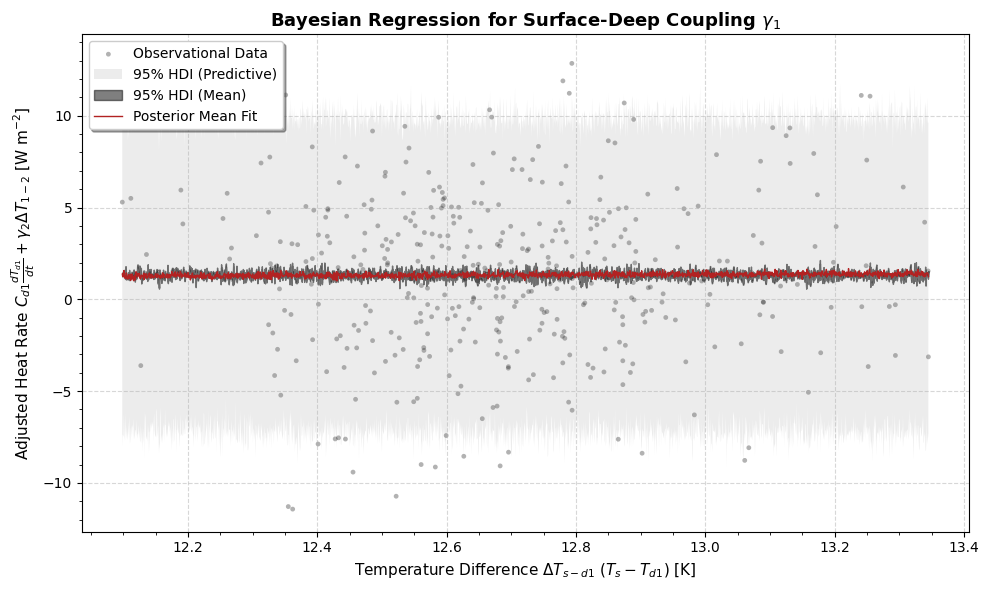

In [60]:
# --- Bayesian Regression for Surface-to-Deep Heat Exchange (Gamma 1) ---

# 1. Prepare data based on the energy balance for the upper deep ocean (layer 1):
# C_d1 * (dTd1/dt) = gamma1 * (Ts - Td1) - gamma2 * (Td1 - Td2)
# To solve for gamma1 using a slope, we define:
# y = C_d1 * dTd1/dt + gamma2_mean * (Td1 - Td2)
# x = Ts - Td1
# The slope of y ~ x then represents gamma1.
data = pd.DataFrame({
    "y": C_d1 * np.gradient(Td1, seconds_per_year/12) + gamma2_mean * (Td1 - Td2),
    "x": Ts - Td1
})

# 2. Fit Bayesian Model through the origin
model_linear = bmb.Model("y ~ 0 + x", data)
idata_linear = model_linear.fit(progressbar=False)

# 3. Generate predictions for visualization
x_range = np.linspace(data['x'].min(), data['x'].max(), 2000)
new_data = pd.DataFrame({"x": x_range})

# Predict the mean (regression line) and the full posterior predictive (observations)
model_linear.predict(idata_linear, data=new_data, kind='response_params')
model_linear.predict(idata_linear, data=new_data, kind='response')

# 4. Extract and reshape posterior draws
y_mean_draws = idata_linear.posterior["mu"].values.reshape(-1, len(x_range))
y_pps_draws = idata_linear.posterior_predictive["y"].values.reshape(-1, len(x_range))

# 5. Compute summary statistics (Mean and 95% HDI)
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(y_mean_draws, prob=0.95)
hdi_pps = az.hdi(y_pps_draws, prob=0.95)

# 6. Visualization setup
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(data['x'], data['y'], color='black', s=12, alpha=0.3, label="Observational Data", edgecolors='none')

# Shade the Predictive HDI (Aleatoric uncertainty / expected noise in data)
plt.fill_between(
    x_range, hdi_pps[:, 0], hdi_pps[:, 1],
    alpha=0.15, color="gray", label="95% HDI (Predictive)", edgecolor=None,)

# Shade the Mean HDI (Epistemic uncertainty / precision of the gamma1 estimate)
plt.fill_between(
    x_range, hdi_mean[:, 0], hdi_mean[:, 1],
    alpha=0.5, color="black", label="95% HDI (Mean)")

# Plot the central posterior mean trend
plt.plot(x_range, posterior_mean, color="firebrick", lw=1, label="Posterior Mean Fit", zorder=4)

# Labeling and Formatting
plt.xlabel(r'Temperature Difference $\Delta T_{s-d1}$ ($T_s - T_{d1}$) [K]', fontsize=11)
plt.ylabel(r'Adjusted Heat Rate $C_{d1} \frac{dT_{d1}}{dt} + \gamma_2 \Delta T_{1-2}$ [W m$^{-2}$]', fontsize=11)
plt.title(r'Bayesian Regression for Surface-Deep Coupling $\gamma_1$', fontsize=13, fontweight='bold')

plt.legend(frameon=True, shadow=True, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.tight_layout()
plt.show()

In [61]:
# --- Posterior Extraction for Surface-Deep Heat Exchange (gamma1) ---

# Extract the posterior samples for the slope 'x' from the inference object.
# In the regression y ~ 0 + x (where y is adjusted heat rate and x is temp gradient),
# the slope 'beta' represents the physical coefficient gamma1.
beta_gamma1 = idata_linear.posterior["x"].values.flatten()

# Map the posterior draws to our physical parameter samples
gamma1_samples = beta_gamma1

# Calculate the expected value (mean) of the coefficient from the posterior distribution
gamma1_mean = gamma1_samples.mean()

# Compute the 95% Highest Density Interval (HDI) using ArviZ.
# This defines the most credible range for gamma1 given the observational data.
gamma1_hdi = az.hdi(gamma1_samples, prob=0.95)

# Display the final derived parameter and its associated uncertainty
print(f"gamma1 = {gamma1_mean:.4f} W m⁻² K⁻¹")
print(f"95% HDI: [{gamma1_hdi[0]:.4f}, {gamma1_hdi[1]:.4f}]")

gamma1 = 0.1044 W m⁻² K⁻¹
95% HDI: [0.0716, 0.1404]


###Albedo

Best-fit albedo parameters:
alpha_min = 0.2762
alpha_max = 0.6830
T_ice    = 267.60 K (-5.55 °C)
delta_T  = 10.66 K


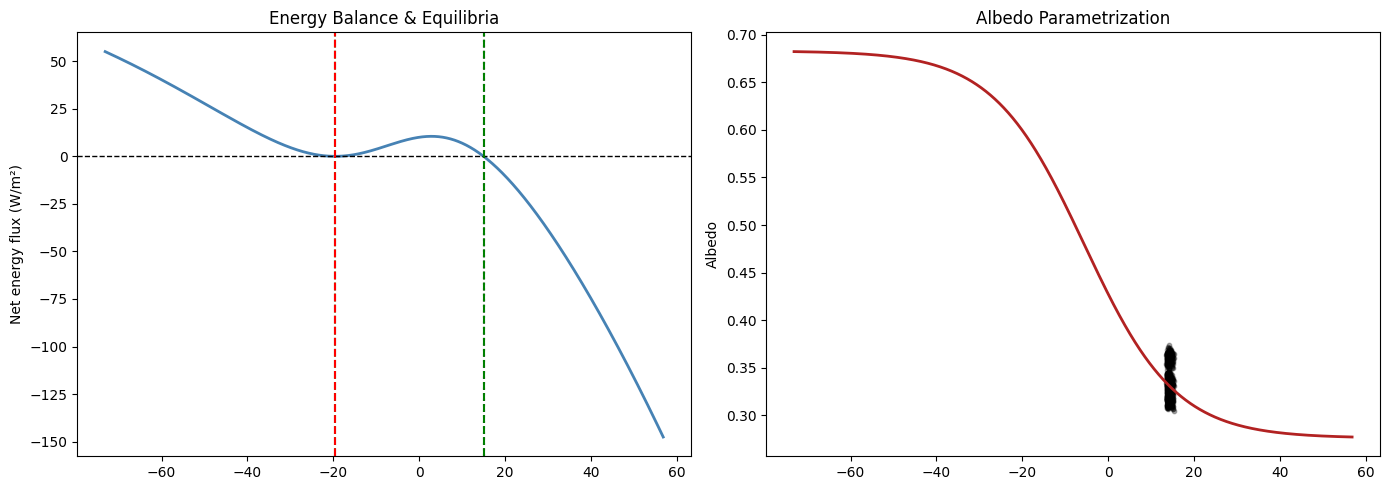

In [62]:
from scipy.optimize import differential_evolution

# ============================================================
# 1. OBSERVATIONAL DATA PREPARATION
# ============================================================
# We align multiple ERA5 and GISS datasets on the 'dt' column to create a
# consistent training set for albedo vs. temperature.

df_albedo = pd.merge(
    df_tnswrf[['dt', 'avg_tnswrf']],
    df_Ts[['dt', 'Surface Temperature']],
    on='dt'
).dropna()

df_albedo = pd.merge(
    df_albedo,
    df_tdswrf[['dt', 'avg_tdswrf']],
    on='dt'
).dropna()

# Extract numpy arrays and convert Ts to Kelvin
Ts_obs = df_albedo['Surface Temperature'].to_numpy() + 273.15
# Calculate observed albedo from Net and Downward Shortwave fluxes
alpha_obs = 1 - (np.abs(df_albedo['avg_tnswrf']) / df_albedo['avg_tdswrf'])

# ============================================================
# 2. MODEL DEFINITIONS
# ============================================================

Ts_range = np.linspace(200, 330, 5000)
T_modern = 288.15

def albedo_func(Ts, alpha_min, alpha_max, T_ice, delta_T):
    """Logistic function representing the temperature-dependent planetary albedo."""
    return alpha_min + (alpha_max - alpha_min) / (
        1 + np.exp((Ts - T_ice) / delta_T)
    )

def net_energy_flux(Ts, alpha_min, alpha_max, T_ice, delta_T):
    """Calculates SW_absorbed - OLR to find energy balance (F=0)."""
    alpha = albedo_func(Ts, alpha_min, alpha_max, T_ice, delta_T)
    SW_absorbed = (1 - alpha) * S0 / 4
    OLR = (1 - epsilon_mean / 2) * sigma * Ts**4
    return SW_absorbed - OLR

def find_equilibria(Ts_range, F):
    """Identifies zero-crossings in the flux and determines their stability."""
    sign_changes = np.where(np.diff(np.sign(F)))[0]
    equilibria = []

    for idx in sign_changes:
        # Linear interpolation for precise crossing point
        T_eq = Ts_range[idx] - F[idx] * (
            Ts_range[idx+1] - Ts_range[idx]
        ) / (F[idx+1] - F[idx])

        # Stable if slope of net flux is negative at crossing (F drops from + to -)
        stable = F[idx] > 0
        equilibria.append((T_eq, stable))

    return equilibria

# ============================================================
# 3. OBJECTIVE FUNCTION FOR OPTIMIZATION
# ============================================================

def objective(params):
    """
    Multi-constraint objective function for Differential Evolution.
    Minimizes albedo error while enforcing a specific EBM structure.
    """
    alpha_min, alpha_max, T_ice, delta_T = params

    # Penalty: Physical constraint (albedo must decrease with T)
    if alpha_max <= alpha_min:
        return 1e9

    # Component 1: Albedo Error (MSE vs. Observations)
    alpha_pred = albedo_func(Ts_obs, alpha_min, alpha_max, T_ice, delta_T)
    albedo_error = np.mean((alpha_obs - alpha_pred)**2)

    # Component 2: Structural Constraints
    # We require the model to exhibit a 'Snowball Earth' state, an unstable
    # transition, and a stable 'Modern Earth' state.
    F = net_energy_flux(Ts_range, alpha_min, alpha_max, T_ice, delta_T)
    equilibria = find_equilibria(Ts_range, F)

    if len(equilibria) != 3:
        return albedo_error + 1e6 # Large penalty if not exactly 3 states

    cold_eq, mid_eq, warm_eq = equilibria
    correct_structure = (cold_eq[1] and not mid_eq[1] and warm_eq[1])

    if not correct_structure:
        return albedo_error + 1e6

    # Component 3: Climate Reality Constraint
    # The warm stable equilibrium MUST be near the observed modern temperature.
    warm_eq_error = ((warm_eq[0] - T_modern) / 5.0)**2

    # Component 4: Weak Priors
    # Gently guide parameters toward physically plausible values.
    prior_error = 0
    prior_error += ((alpha_min - 0.25) / 0.08)**2 * 0.01
    prior_error += ((alpha_max - 0.65) / 0.15)**2 * 0.01
    prior_error += ((T_ice - 265) / 10)**2 * 0.01
    prior_error += ((delta_T - 10) / 5)**2 * 0.01

    return albedo_error + warm_eq_error + prior_error

# ============================================================
# 4. OPTIMIZATION EXECUTION
# ============================================================

bounds = [
    (0.10, 0.35),   # alpha_min bounds
    (0.45, 0.85),   # alpha_max bounds
    (245, 285),     # T_ice (transition center) bounds
    (2, 25)         # delta_T (transition width) bounds
]

# Use Differential Evolution for global search (robust to local minima)
result = differential_evolution(
    objective,
    bounds=bounds,
    seed=42,
    tol=1e-7,
    polish=True
)

alpha_min_fit, alpha_max_fit, T_ice_fit, delta_T_fit = result.x

# Print Summary
print("Best-fit albedo parameters:")
print(f"alpha_min = {alpha_min_fit:.4f}")
print(f"alpha_max = {alpha_max_fit:.4f}")
print(f"T_ice    = {T_ice_fit:.2f} K ({T_ice_fit - 273.15:.2f} °C)")
print(f"delta_T  = {delta_T_fit:.2f} K")

# Update global variables for use in subsequent simulation cells
alpha_min, alpha_max, T_ice, delta_T = result.x

# ============================================================
# 5. DIAGNOSTIC VISUALIZATION
# ============================================================

F_best = net_energy_flux(Ts_range, alpha_min, alpha_max, T_ice, delta_T)
alpha_curve = albedo_func(Ts_range, alpha_min, alpha_max, T_ice, delta_T)
equilibria = find_equilibria(Ts_range, F_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Energy Balance
axes[0].plot(Ts_range - 273.15, F_best, color='steelblue', lw=2)
axes[0].axhline(0, color='black', ls='--', lw=1)
axes[0].axvline(T_modern - 273.15, color='black', ls=':', label='Modern Earth')
for T_eq, stable in equilibria:
    axes[0].axvline(T_eq - 273.15, color='green' if stable else 'red', ls='--')
axes[0].set_title('Energy Balance & Equilibria')
axes[0].set_ylabel('Net energy flux (W/m²)')

# Plot B: Albedo Curve Fit
axes[1].scatter(Ts_obs - 273.15, alpha_obs, s=10, alpha=0.3, color='black', label='Observations')
axes[1].plot(Ts_range - 273.15, alpha_curve, color='firebrick', lw=2, label='Fitted Model')
axes[1].set_title('Albedo Parametrization')
axes[1].set_ylabel('Albedo')

plt.tight_layout()
plt.show()

In [63]:
from scipy.optimize import differential_evolution
import arviz as az

n_bootstrap = 50   # increase to 500+ for publication quality
n_obs = len(Ts_obs)

# Storage
boot_params = np.zeros((n_bootstrap, 4))
# cols: alpha_min, alpha_max, T_ice, delta_T

print(f"Running {n_bootstrap} bootstrap resamples...")
for b in range(n_bootstrap):
    if b % 25 == 0:
        print(f"  {b}/{n_bootstrap}")

    # Resample observations with replacement
    idx        = np.random.choice(n_obs, n_obs, replace=True)
    Ts_boot    = Ts_obs[idx]
    alpha_boot = alpha_obs.values[idx]

    # Redefine objective using bootstrap sample
    def objective_boot(params):
        a_min, a_max, T_i, dT = params
        if a_max <= a_min:
            return 1e9
        alpha_pred  = albedo_func(Ts_boot, a_min, a_max, T_i, dT)
        albedo_error = np.mean((alpha_boot - alpha_pred)**2)
        F           = net_energy_flux(Ts_range, a_min, a_max, T_i, dT)
        equilibria  = find_equilibria(Ts_range, F)
        if len(equilibria) != 3:
            return albedo_error + 1e6
        cold_eq, mid_eq, warm_eq = equilibria
        if not (cold_eq[1] and not mid_eq[1] and warm_eq[1]):
            return albedo_error + 1e6
        warm_eq_error = ((warm_eq[0] - T_modern) / 5.0)**2
        prior_error   = (((a_min-0.25)/0.08)**2 + ((a_max-0.65)/0.15)**2
                        + ((T_i-265)/10)**2 + ((dT-10)/5)**2) * 0.01
        return albedo_error + warm_eq_error + prior_error

    result_b = differential_evolution(
        objective_boot, bounds=bounds, seed=b, tol=1e-6, polish=True,
        maxiter=50   # fewer iterations per bootstrap for speed
    )
    boot_params[b] = result_b.x

# ── Summarise distributions ───────────────────────────────────────────────────
param_names = ['alpha_min', 'alpha_max', 'T_ice', 'delta_T']
for j, name in enumerate(param_names):
    samples = boot_params[:, j]
    hdi     = az.hdi(samples, prob=0.95)
    print(f"{name:12s}: mean={samples.mean():.4f}  "
          f"std={samples.std():.4f}  "
          f"95% HDI [{hdi[0]:.4f}, {hdi[1]:.4f}]")

# Store as named arrays for Monte Carlo
alpha_min_samples = boot_params[:, 0]
alpha_max_samples = boot_params[:, 1]
T_ice_samples     = boot_params[:, 2]
delta_T_samples   = boot_params[:, 3]

Running 50 bootstrap resamples...
  0/50
  25/50
alpha_min   : mean=0.2763  std=0.0017  95% HDI [0.2727, 0.2787]
alpha_max   : mean=0.6828  std=0.0020  95% HDI [0.6790, 0.6860]
T_ice       : mean=267.6303  std=0.2261  95% HDI [267.2385, 268.0176]
delta_T     : mean=10.6396  std=0.1135  95% HDI [10.4494, 10.8223]


####Brute force Least squares

In [64]:
# Define the range of possible values for the ice temperature (T_ice) and transition width (delta_T)
# These ranges are used in a brute-force search to find the best-fit albedo parameters.
#T_ice_values = np.linspace(250, 280, 200) # Ice temperature in Kelvin (e.g., 250K to 280K)
#delta_T_values = np.linspace(5, 25, 100) # Temperature range for the albedo transition in Kelvin

# -----------------------------------------------------------------------------
# Data Preparation: Merge relevant datasets for albedo model fitting
# -----------------------------------------------------------------------------
# Merge surface temperature (df_Ts) and forecast albedo (df_FAL)
#df_albedo = pd.merge(
    #df_FAL[['dt', 'fal']],
    #df_Ts[['dt', 'Surface Temperature']],
    #on='dt'
#).dropna() # Drop rows with missing values after merging

# Extract observed surface temperatures (Ts_obs) and convert to Kelvin
#Ts_obs = df_albedo['Surface Temperature'].to_numpy() + 273.15

# Extract observed albedo (alpha_obs) using 'fal' (fractional albedo).
# The commented-out line shows an alternative calculation using net and downward shortwave radiation.
#alpha_obs = df_albedo['fal'] #1 - (np.abs(df_albedo['avg_tnswrf']) / df_albedo['avg_tdswrf'])

# -----------------------------------------------------------------------------
# Brute-Force Search for Optimal Ice-Albedo Feedback Parameters
# -----------------------------------------------------------------------------

# Initialize variables to store the best parameters found and the corresponding error
#best_error = np.inf # Start with an infinitely large error
#T_ice = None         # Optimal ice temperature
#delta_T = None       # Optimal transition width

# Loop through all combinations of T_ice and delta_T values
#for T_ice_test in T_ice_values:
    #for delta_T_test in delta_T_values:

        # Calculate the modeled albedo (alpha_model) using the current test parameters
        # This uses a logistic function to represent the albedo's dependence on surface temperature.
        #alpha_model = alpha_min + (alpha_max - alpha_min) / (
         #   1 + np.exp((Ts_obs - T_ice_test) / delta_T_test)
        #)

        # Calculate the mean squared error between observed and modeled albedo
        #error = np.mean((alpha_obs - alpha_model)**2)

        # If the current error is lower than the best_error found so far, update the best parameters
        #if error < best_error:
           # best_error = error
           # T_ice = T_ice_test
           # delta_T = delta_T_test

# Print the optimal T_ice, delta_T, and the minimum mean squared error found
#print(T_ice, delta_T, best_error)

#Model

## Setup

In [65]:
# --- CONSOLIDATED MODEL PARAMETERS ---

# --- Radiative & Coupling Parameters ---
# Derived from Bayesian linear regressions (mean of posterior distributions)
epsilon   = epsilon_mean  # Atmospheric emissivity
gamma1    = gamma1_mean   # Surface-to-Deep Ocean coupling coefficient (W/m²/K)
gamma2    = gamma2_mean   # Deep-to-Abyssal Ocean coupling coefficient (W/m²/K)

# --- Ice-Albedo Feedback Parameters ---
# Derived from Differential Evolution optimization and bootstrap analysis
alpha_min = alpha_min     # Minimum planetary albedo (ice-free)
alpha_max = alpha_max     # Maximum planetary albedo (glaciated)
T_ice     = T_ice         # Critical temperature threshold for ice transition (K)
delta_T   = delta_T       # Width/smoothness of the albedo transition (K)

# --- Layer Heat Capacities (J/m²/K) ---
# Derived from physical layer depths and material properties
Cs  = C_s                 # Surface (Mixed Layer + Land) heat capacity
Ca1 = Ca1                 # Upper Atmospheric layer heat capacity
Ca2 = Ca2                 # Lower Atmospheric layer heat capacity
Cd1 = C_d1                # Upper Deep Ocean heat capacity
Cd2 = C_d2                # Lower Deep Ocean heat capacity

# --- Forcing & Variability Parameters ---
# Solar, CO2, Volcanic, and Stochastic noise terms
S0        = S0            # Baseline Total Solar Irradiance (TSI)
A11       = A11           # Amplitude of the 11-year solar cycle
A22       = A22           # Amplitude of the 22-year solar cycle
C0        = 280.0         # Pre-industrial/Reference CO2 concentration (ppm)
eruption_probability = 0.01 # Annual probability of a major volcanic event
noise_std  = 4          # Standard deviation of weather noise

# --- PARAMETER UNCERTAINTIES (1-Sigma) ---

# Uncertainties from Bayesian Posterior Spreads
epsilon_unc   = epsilon_samples.std()
gamma1_unc    = gamma1_samples.std()
gamma2_unc    = gamma2_samples.std()

# Uncertainties from Bootstrap Resampling
alpha_min_unc = alpha_min_samples.std()
alpha_max_unc = alpha_max_samples.std()
T_ice_unc     = T_ice_samples.std()
delta_T_unc   = delta_T_samples.std()

# Structural Estimates (10-15% relative uncertainty)
C_s_unc  = 0.10 * Cs
C_a1_unc = 0.10 * Ca1
C_a2_unc = 0.10 * Ca2
C_d1_unc = 0.10 * Cd1
C_d2_unc = 0.10 * Cd2

A11_unc = 0.15 * A11
A22_unc = 0.15 * A22

# Stochastic Uncertainty
noise_unc = noise_std

# --- SUMMARY PRINTOUT ---

print("\n--- GLOBAL MODEL CONFIGURATION ---")
print("="*50)
print(f"Emissivity (ε):      {epsilon:.4f} ± {epsilon_unc:.4f}")
print(f"Ocean Coupling γ1:   {gamma1:.4f} ± {gamma1_unc:.4f} W/m²/K")
print(f"Ocean Coupling γ2:   {gamma2:.4f} ± {gamma2_unc:.4f} W/m²/K")
print(f"Albedo (Min):       {alpha_min:.4f} ± {alpha_min_unc:.4f}")
print(f"Albedo (Max):       {alpha_max:.4f} ± {alpha_max_unc:.4f}")
print(f"Ice Threshold:      {T_ice:.2f} ± {T_ice_unc:.2f} K")
print(f"Surface Cap (Cs):   {Cs:.3e} ± {C_s_unc:.3e} J/m²/K")
print(f"Atmos Cap (Ca1):    {Ca1:.3e} ± {C_a1_unc:.3e} J/m²/K")
print(f"Atmos Cap (Ca2):    {Ca2:.3e} ± {C_a2_unc:.3e} J/m²/K")
print(f"Deep Ocean (Cd1):   {Cd1:.3e} ± {C_d1_unc:.3e} J/m²/K")
print(f"Deep Ocean (Cd2):   {Cd2:.3e} ± {C_d2_unc:.3e} J/m²/K")
print(f"Solar Baseline S0:  {S0:.2f} W/m²")
print(f"Solar Amp (11-yr):  {A11:.3f} ± {A11_unc:.3f}")
print(f"Solar Amp (22-yr):  {A22:.3f} ± {A22_unc:.3f}")
print(f"Reference CO2 (C0): {C0:.1f} ppm")
print(f"Eruption Prob:      {eruption_probability:.3f} (yr⁻¹)")
print(f"Noise Term:         {noise_std:.2f} ± {noise_unc:.2f}")


--- GLOBAL MODEL CONFIGURATION ---
Emissivity (ε):      0.8294 ± 0.0005
Ocean Coupling γ1:   0.1044 ± 0.0174 W/m²/K
Ocean Coupling γ2:   0.5312 ± 0.0998 W/m²/K
Albedo (Min):       0.2762 ± 0.0017
Albedo (Max):       0.6830 ± 0.0020
Ice Threshold:      267.60 ± 0.23 K
Surface Cap (Cs):   1.460e+08 ± 1.460e+07 J/m²/K
Atmos Cap (Ca1):    3.070e+06 ± 3.070e+05 J/m²/K
Atmos Cap (Ca2):    7.164e+06 ± 7.164e+05 J/m²/K
Deep Ocean (Cd1):   8.200e+09 ± 8.200e+08 J/m²/K
Deep Ocean (Cd2):   1.640e+10 ± 1.640e+09 J/m²/K
Solar Baseline S0:  1361.69 W/m²
Solar Amp (11-yr):  0.476 ± 0.071
Solar Amp (22-yr):  0.178 ± 0.027
Reference CO2 (C0): 280.0 ppm
Eruption Prob:      0.010 (yr⁻¹)
Noise Term:         4.00 ± 4.00


##Model

###Initialise Time-Step

In [71]:
# --- MONTE CARLO TIME-STEP INITIALIZATION ---

# Number of independent model realisations in the ensemble
n_runs = 250       # Recommended: 50+ for testing, 200+ for stable statistics

# Total simulation duration in years
years = 200

# Numerical integration time step in years
dt = 0.01

# Total number of discrete integration steps
n_steps = int(years / dt)

# Linear time array for plotting and tracking forcing functions
time = np.linspace(0, years, n_steps)

# Convert the yearly time step into seconds for use in differential equations
dt_sec = dt * seconds_per_year

###Model Helper Functions

In [72]:
# --- MONTE CARLO ENSEMBLE HELPER FUNCTIONS ---

def sample_parameters():
    """
    Generates a unique set of model parameters for a single ensemble member.

    This function combines:
    1. Empirical samples from Bayesian posteriors and bootstrap results.
    2. Structural uncertainty drawn from normal distributions around physical estimates.
    3. Safety clipping to ensure parameters remain within physically plausible ranges.
    """
    params = {}

    # --- Empirical Posterior / Bootstrap Samples ---
    # Drawing from derived distributions to account for observational uncertainty
    params["epsilon"]   = np.random.choice(epsilon_samples)
    params["gamma1"]    = np.random.choice(gamma1_samples)
    params["gamma2"]    = np.random.choice(gamma2_samples)

    params["alpha_min"] = np.random.choice(alpha_min_samples)
    params["alpha_max"] = np.random.choice(alpha_max_samples)
    params["T_ice"]     = np.random.choice(T_ice_samples)
    params["delta_T"]   = np.random.choice(delta_T_samples)

    # --- Structural Uncertainty Sampling ---
    # Assuming 10-15% uncertainty for constants derived from physical properties
    params["Cs"]  = np.random.normal(Cs,  C_s_unc)
    params["Ca1"] = np.random.normal(Ca1, C_a1_unc)
    params["Ca2"] = np.random.normal(Ca2, C_a2_unc)
    params["Cd1"] = np.random.normal(Cd1, C_d1_unc)
    params["Cd2"] = np.random.normal(Cd2, C_d2_unc)

    # Solar cycle amplitude uncertainty
    params["A11"] = np.random.normal(A11, A11_unc)
    params["A22"] = np.random.normal(A22, A22_unc)

    # Stochastic weather noise standard deviation uncertainty
    params["noise_std"] = np.abs(np.random.normal(noise_std, noise_unc))

    # CO2 scenario uncertainty
    params["co2_scale"] = np.random.normal(1.0, 0.20)      # ±20% growth uncertainty

    # --- Safety Clipping & Physical Constraints ---
    # Prevents numerical instability and ensures thermodynamic consistency
    params["epsilon"] = np.clip(params["epsilon"], 0.05, 0.95)
    params["gamma1"]  = np.clip(params["gamma1"], 0.001, 5)
    params["gamma2"]  = np.clip(params["gamma2"], 0.001, 5)
    params["co2_scale"] = np.clip(params["co2_scale"], 0.5, 1.8)

    params["alpha_min"] = np.clip(params["alpha_min"], 0.05, 0.40)
    params["alpha_max"] = np.clip(params["alpha_max"], 0.40, 0.90)

    # Ensure the albedo range is sufficient for bistability
    if params["alpha_max"] <= params["alpha_min"]:
        params["alpha_max"] = params["alpha_min" ] + 0.2

    params["delta_T"] = np.clip(params["delta_T"], 1, 30)

    return params

def Solar_Insolation_MC(t, params):
    """
    Calculates time-dependent solar forcing using ensemble-specific cycle amplitudes.

    Parameters:
    t (float): Time in years.
    params (dict): Sampled parameter set containing A11 and A22 amplitudes.
    """
    cycle11 = params["A11"] * np.cos(2 * np.pi * t / 11 + phi11)
    cycle22 = params["A22"] * np.cos(2 * np.pi * t / 22 + phi22)
    return S0 + cycle11 + cycle22

def generate_volcanic_forcing():
    """
    Generates a stochastic volcanic forcing time-series (Negative Radiative Forcing).

    Each time-step has a small probability of triggering an eruption.
    Eruptions result in an immediate negative forcing followed by an
    exponential decay representing the settling of stratospheric aerosols.
    """
    F_volc = np.zeros(n_steps)

    for i in range(n_steps):
        # Stochastic check for eruption event
        if np.random.rand() < eruption_probability * dt:

            # Randomize eruption magnitude (Negative forcing in W/m^2)
            strength = -np.abs(np.random.normal(loc=0, scale=2.5))
            strength = np.clip(strength, -8, -0.1)

            # Randomize decay timescale (1 to 3 years)
            tau = np.random.uniform(1, 3)

            # Apply exponential decay to all subsequent time steps
            for j in range(i, n_steps):
                t_since = time[j] - time[i]
                F_volc[j] += strength * np.exp(-t_since / tau)

    return F_volc

def CO2_MC(t, params):
    """
    Monte Carlo CO2 pathway.
    Starts from observed fitted CO2, then perturbs growth/curvature.
    """

    # Baseline fitted CO2 from your polynomial + seasonal cycle
    baseline_CO2 = CO2_growth_rate(t)

    # Reference start value
    CO2_start = CO2_growth_rate(0)

    CO2_sampled = CO2_start + params["co2_scale"] * (baseline_CO2 - CO2_start)

    return max(CO2_sampled, 1)

###Spin-up

In [73]:
def run_spinup(params, spinup_years=1000, dt=0.01):
    """
    Runs the Energy Balance Model to a steady-state equilibrium (spin-up).

    This function integrates the 5-layer system over a long duration to ensure that
    the high-inertia layers, particularly the deep ocean (Cd1, Cd2), reach thermal
    equilibrium with pre-industrial forcing before the main simulation begins.

    Parameters:
    ----------
    params : dict
        Physical constants and feedback coefficients (epsilon, gamma, alpha, etc.).
    spinup_years : int, default=1000
        Duration of the spin-up period in years.
    dt : float, default=0.01
        Integration time step in years.

    Returns:
    -------
    spun_up_state : dict
        Dictionary containing the final equilibrium temperatures for all 5 layers:
        Ts0, Ta20, Ta10, Td10, Td20.
    """
    # --- Integration Setup ---
    # Calculate total steps and time step in seconds for numerical stability
    spin_steps = int(spinup_years / dt)
    spin_time = np.linspace(0, spinup_years, spin_steps)
    dt_sec_spin = dt * seconds_per_year

    # Initialize temperature arrays for the 5-layer system
    Ts  = np.zeros(spin_steps)  # Surface
    Ta2 = np.zeros(spin_steps)  # Lower Atmosphere
    Ta1 = np.zeros(spin_steps)  # Upper Atmosphere
    Td1 = np.zeros(spin_steps)  # Upper Deep Ocean
    Td2 = np.zeros(spin_steps)  # Lower Deep Ocean

    # Set physically grounded initial temperature guesses (Kelvin)
    Ts[0]  = 288.15
    Ta2[0] = 255.0
    Ta1[0] = 230.0
    Td1[0] = 277.0
    Td2[0] = 275.0

    # Set forcing conditions to pre-industrial baselines
    CO2_pi = C0
    S_pi = S0

    # --- Numerical Integration Loop ---
    for i in range(spin_steps - 1):

        # 1. Calculate ice-albedo feedback (logistic transition)
        alpha = params["alpha_min"] + (
            params["alpha_max"] - params["alpha_min"]
        ) / (
            1 + np.exp((Ts[i] - params["T_ice"]) / params["delta_T"])
        )

        # 2. Calculate logarithmic CO2 forcing
        F_co2 = 5.35 * np.log(CO2_pi / C0)

        # 3. Surface Energy Balance Equation
        dTs_dt = (
              (1 - alpha) * S_pi / 4
            + params["epsilon"] * sigma * Ta2[i]**4
            + (1 - params["epsilon"]) * params["epsilon"] * sigma * Ta1[i]**4
            - sigma * Ts[i]**4
            + F_co2
            - params["gamma1"] * (Ts[i] - Td1[i])
        ) / params["Cs"]

        # 4. Lower Atmosphere Energy Balance Equation
        dTa2_dt = (
              params["epsilon"] * sigma * Ts[i]**4
            + params["epsilon"]**2 * sigma * Ta1[i]**4
            - 2 * params["epsilon"] * sigma * Ta2[i]**4
        ) / params["Ca2"]

        # 5. Upper Atmosphere Energy Balance Equation
        dTa1_dt = (
              params["epsilon"] * (1 - params["epsilon"]) * sigma * Ts[i]**4
            + params["epsilon"]**2 * sigma * Ta2[i]**4
            - 2 * params["epsilon"] * sigma * Ta1[i]**4
        ) / params["Ca1"]

        # 6. Upper Deep Ocean Heat Exchange
        dTd1_dt = (
              params["gamma1"] * (Ts[i] - Td1[i])
            - params["gamma2"] * (Td1[i] - Td2[i])
        ) / params["Cd1"]

        # 7. Lower Deep Ocean (Abyssal) Heat Exchange
        dTd2_dt = (
            params["gamma2"] * (Td1[i] - Td2[i])
        ) / params["Cd2"]

        # 8. Step forward using Euler integration
        Ts[i+1]  = Ts[i]  + dTs_dt  * dt_sec_spin
        Ta2[i+1] = Ta2[i] + dTa2_dt * dt_sec_spin
        Ta1[i+1] = Ta1[i] + dTa1_dt * dt_sec_spin
        Td1[i+1] = Td1[i] + dTd1_dt * dt_sec_spin
        Td2[i+1] = Td2[i] + dTd2_dt * dt_sec_spin

    # Compile the final equilibrium states into a dictionary
    spun_up_state = {
        "Ts0": Ts[-1],
        "Ta20": Ta2[-1],
        "Ta10": Ta1[-1],
        "Td10": Td1[-1],
        "Td20": Td2[-1]
    }

    return spun_up_state

###Model

In [74]:
def run_model(params, state0 = None):
    """
    Executes a single integration of the 5-layer Energy Balance Model (EBM).

    Layers included:
    - Surface (Ts): Combined land and ocean mixed layer
    - Lower Atmosphere (Ta2): Higher pressure, lower altitude (closer to surface)
    - Upper Atmosphere (Ta1): Lower pressure, higher altitude
    - Upper Deep Ocean (Td1): 0-2000m depth
    - Lower Deep Ocean (Td2): 2000-6000m depth

    Parameters:
    params (dict): A dictionary containing sampled physical constants and
                   feedback coefficients for this ensemble member.

    Returns:
    Ts (ndarray): Time-series of surface temperature (K).
    """
    # --- Initialize State Arrays ---
    Ts  = np.zeros(n_steps)
    Ta2 = np.zeros(n_steps)
    Ta1 = np.zeros(n_steps)
    Td1 = np.zeros(n_steps)
    Td2 = np.zeros(n_steps)

    # Generate a unique volcanic forcing time-series for this run
    F_volc = generate_volcanic_forcing()

    # --- Initial Conditions (Standard Modern Earth Estimates in Kelvin) ---
    state0 = run_spinup(params)

    Ts[0]  = state0["Ts0"]
    Ta2[0] = state0["Ta20"]
    Ta1[0] = state0["Ta10"]
    Td1[0] = state0["Td10"]
    Td2[0] = state0["Td20"]

    # --- Core Integration Loop (Euler Method) ---
    for i in range(n_steps - 1):
        t = time[i]

        # 1. Calculate External and Feedback Forcings
        S = Solar_Insolation_MC(t, params)  # Time-varying solar irradiance

        # Ice-Albedo Feedback (Logistic transition based on surface temperature)
        alpha = params["alpha_min"] + (
            params["alpha_max"] - params["alpha_min"]
        ) / (
            1 + np.exp((Ts[i] - params["T_ice"]) / params["delta_T"])
        )

        # Anthropogenic CO2 Forcing (Logarithmic relationship)
        current_CO2 = CO2_MC(t, params)
        F_co2 = 5.35 * np.log(current_CO2 / C0)

        # Stochastic Weather Noise
        noise = np.random.normal(0, params["noise_std"])

        # 2. Define Differential Equations (Energy Flux Balance)

        # Surface Layer: Absorbed SW + Back-radiation - Emission + CO2 + Coupling + Volcanic + Noise
        # Back-radiation comes primarily from the lower atmosphere (Ta2)
        dTs_dt = (
              (1 - alpha) * S / 4
            + params["epsilon"] * sigma * Ta2[i]**4
            + (1 - params["epsilon"]) * params["epsilon"] * sigma * Ta1[i]**4
            - sigma * Ts[i]**4
            + F_co2
            - params["gamma1"] * (Ts[i] - Td1[i])
            + F_volc[i]
            + noise
        ) / params["Cs"]

        # Lower Atmosphere (Ta2) - Interacts with Surface and Upper Atmosphere
        dTa2_dt = (
              params["epsilon"] * sigma * Ts[i]**4
            + params["epsilon"]**2 * sigma * Ta1[i]**4
            - 2 * params["epsilon"] * sigma * Ta2[i]**4
        ) / params["Ca2"]

        # Upper Atmosphere (Ta1) - Interacts with Lower Atmosphere and Space
        dTa1_dt = (
              params["epsilon"] * (1 - params["epsilon"]) * sigma * Ts[i]**4
            + params["epsilon"]**2 * sigma * Ta2[i]**4
            - 2 * params["epsilon"] * sigma * Ta1[i]**4
        ) / params["Ca1"]

        # Upper Deep Ocean (Coupled to surface and abyssal layer)
        dTd1_dt = (
              params["gamma1"] * (Ts[i] - Td1[i])
            - params["gamma2"] * (Td1[i] - Td2[i])
        ) / params["Cd1"]

        # Lower Deep Ocean (Abyssal layer)
        dTd2_dt = (
            params["gamma2"] * (Td1[i] - Td2[i])
        ) / params["Cd2"]

        # 3. Update State Vectors
        Ts[i+1]  = Ts[i]  + dTs_dt  * dt_sec
        Ta2[i+1] = Ta2[i] + dTa2_dt * dt_sec
        Ta1[i+1] = Ta1[i] + dTa1_dt * dt_sec
        Td1[i+1] = Td1[i] + dTd1_dt * dt_sec
        Td2[i+1] = Td2[i] + dTd2_dt * dt_sec

    return Ts, Ta2, Ta1, Td1, Td2

###Monte Carlo Ensemble

In [75]:
# --- ENSEMBLE EXECUTION & STATISTICAL ANALYSIS ---

# 1. Initialize storage for all layer temperature results
# Rows represent independent ensemble members (runs), columns represent time steps
Ts_ensemble = np.zeros((n_runs, n_steps))
Ta1_ensemble = np.zeros((n_runs, n_steps))
Ta2_ensemble = np.zeros((n_runs, n_steps))
Td1_ensemble = np.zeros((n_runs, n_steps))
Td2_ensemble = np.zeros((n_runs, n_steps))
spinup_states = []
params_used = []

# 2. Main Monte Carlo Loop
for r in range(n_runs):
    # Sample a unique set of physical parameters from the derived distributions

    params = sample_parameters()
    params_used.append(params)

    # Run preindustrial spin-up for this parameter set
    spinup_result = run_spinup(params, spinup_years=3000, dt=0.01)

    # Extract final spun-up state
    state0 = spinup_result
    spinup_states.append(state0)

    # Execute the 5-layer Energy Balance Model integration for this parameter set
    Ts_ensemble[r, :], Ta2_ensemble[r, :], Ta1_ensemble[r, :], Td1_ensemble[r, :], Td2_ensemble[r, :] = run_model(params, state0=state0)

    # Progress tracking
    if r % 10 == 0:
        print(f"Completed run {r}/{n_runs}")

# 3. Post-Processing: Convert from Kelvin to Celsius
Ts_ensemble_C  = Ts_ensemble - 273.15
Ta2_ensemble_C = Ta2_ensemble - 273.15
Ta1_ensemble_C = Ta1_ensemble - 273.15
Td1_ensemble_C = Td1_ensemble - 273.15
Td2_ensemble_C = Td2_ensemble - 273.15

# 4. Statistical Aggregation
# Calculate the ensemble mean and specific percentiles to define uncertainty bands
# axis=0 performs the calculation across all runs for every individual time step
Ts_mean  = np.mean(Ts_ensemble_C, axis=0)
Ta2_mean = np.mean(Ta2_ensemble_C, axis=0)
Ta1_mean = np.mean(Ta1_ensemble_C, axis=0)
Td1_mean = np.mean(Td1_ensemble_C, axis=0)
Td2_mean = np.mean(Td2_ensemble_C, axis=0)
Ts_p05   = np.percentile(Ts_ensemble_C, 5, axis=0)  # 5th percentile (Lower bound)
Ts_p25   = np.percentile(Ts_ensemble_C, 25, axis=0) # 25th percentile
Ts_p75   = np.percentile(Ts_ensemble_C, 75, axis=0) # 75th percentile
Ts_p95   = np.percentile(Ts_ensemble_C, 95, axis=0) # 95th percentile (Upper bound)

Completed run 0/250
Completed run 10/250
Completed run 20/250
Completed run 30/250
Completed run 40/250
Completed run 50/250
Completed run 60/250
Completed run 70/250
Completed run 80/250
Completed run 90/250
Completed run 100/250
Completed run 110/250
Completed run 120/250
Completed run 130/250
Completed run 140/250
Completed run 150/250
Completed run 160/250
Completed run 170/250
Completed run 180/250
Completed run 190/250
Completed run 200/250
Completed run 210/250
Completed run 220/250
Completed run 230/250
Completed run 240/250


#Visualisation

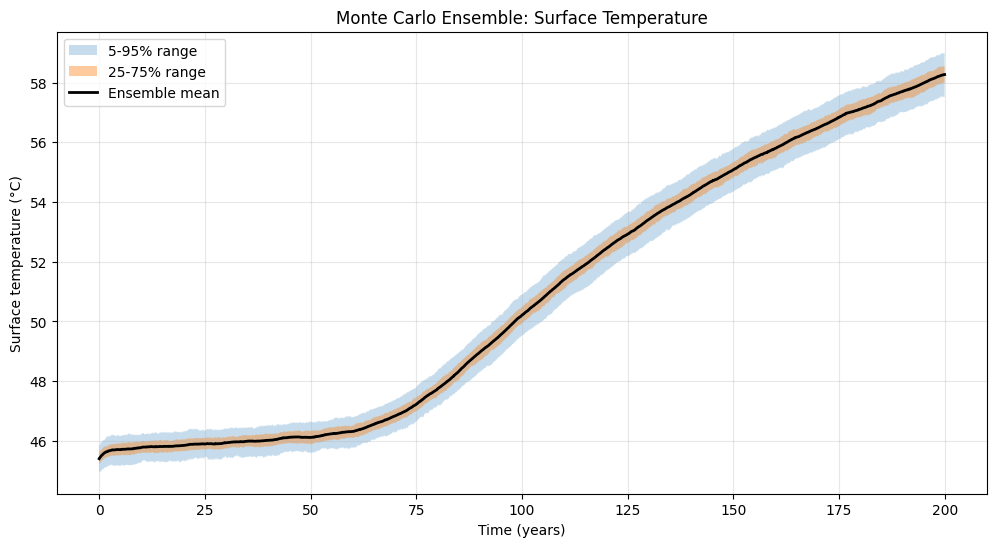

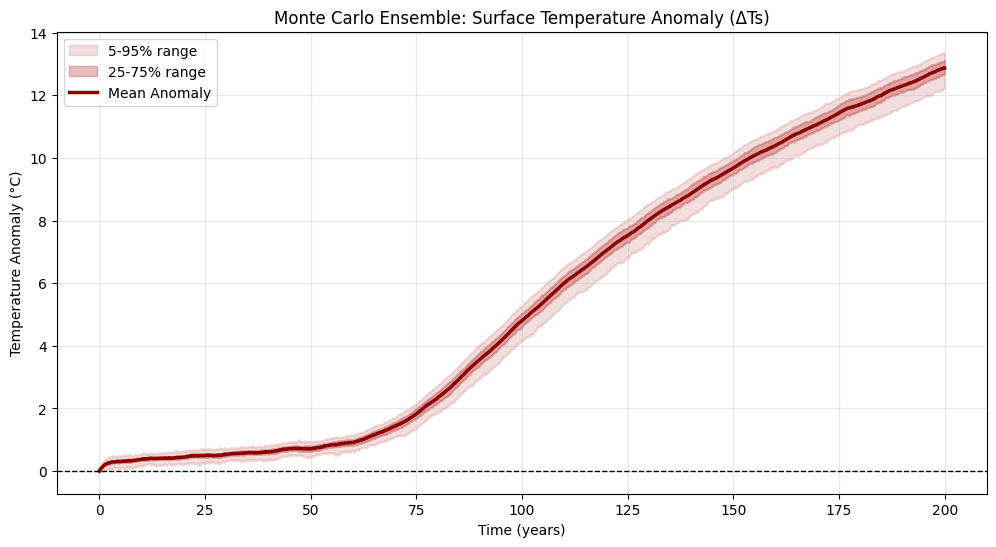

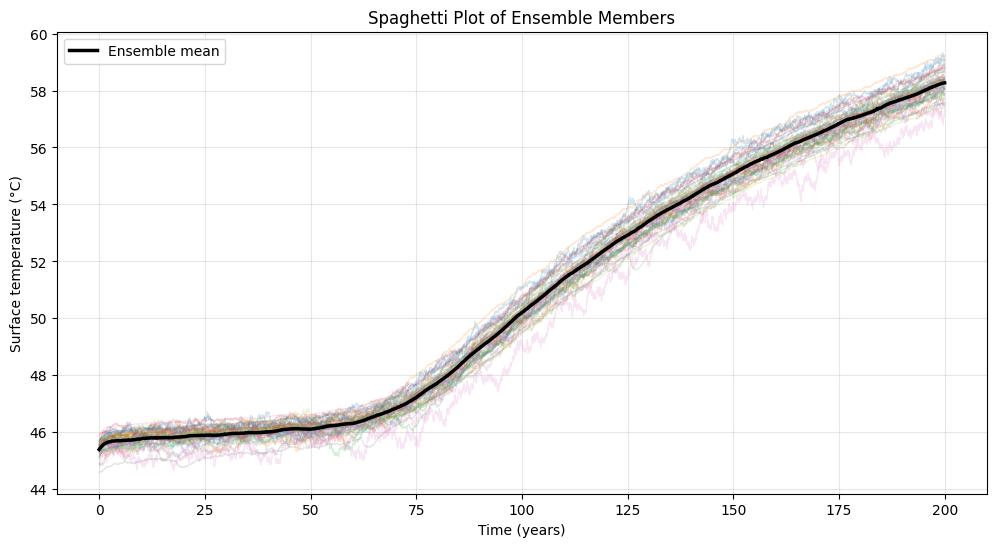

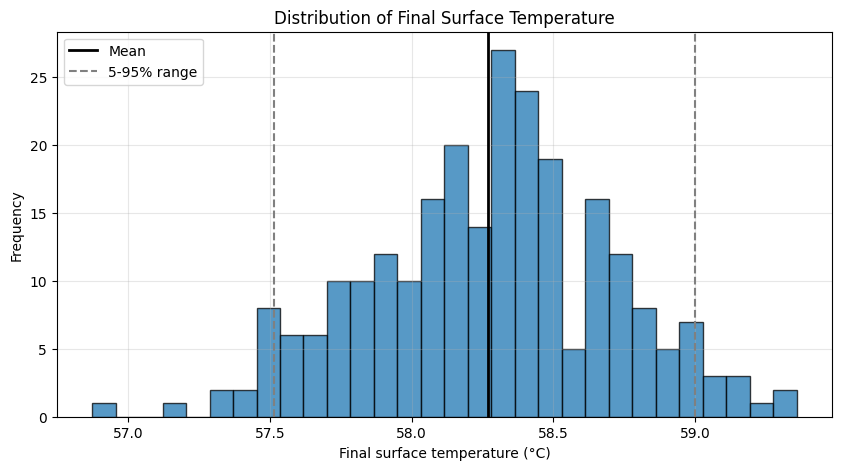

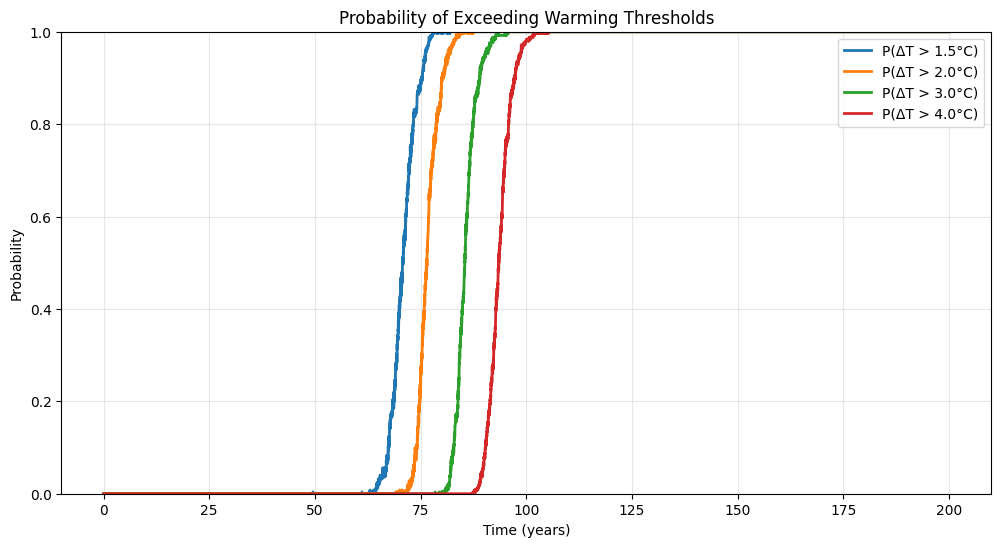

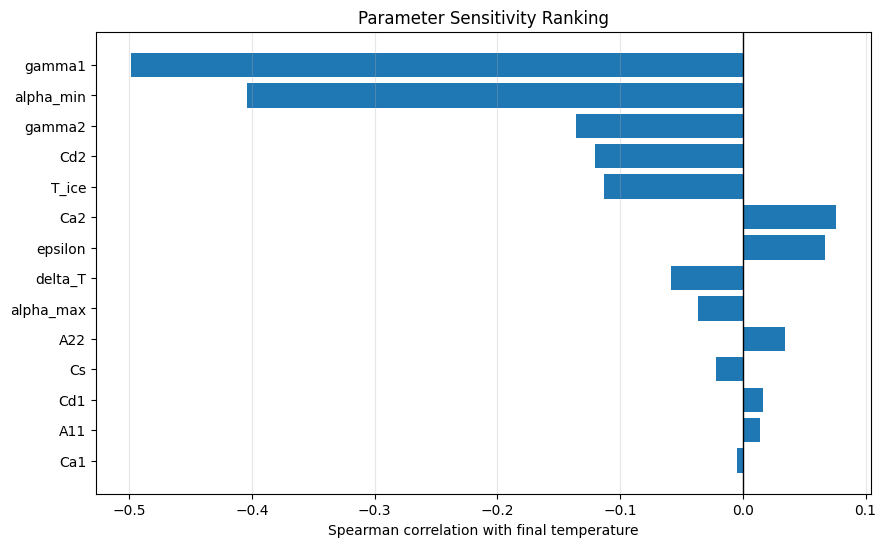

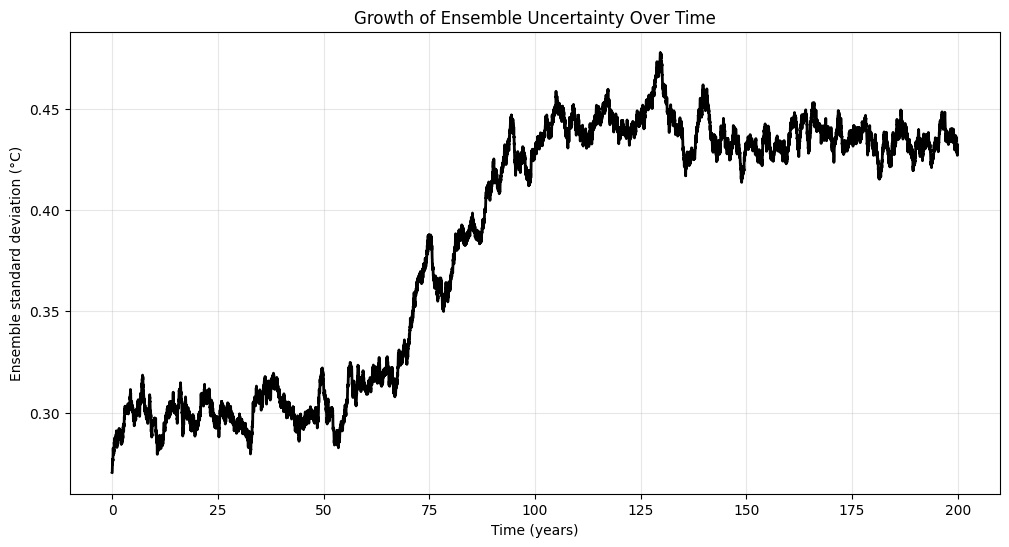

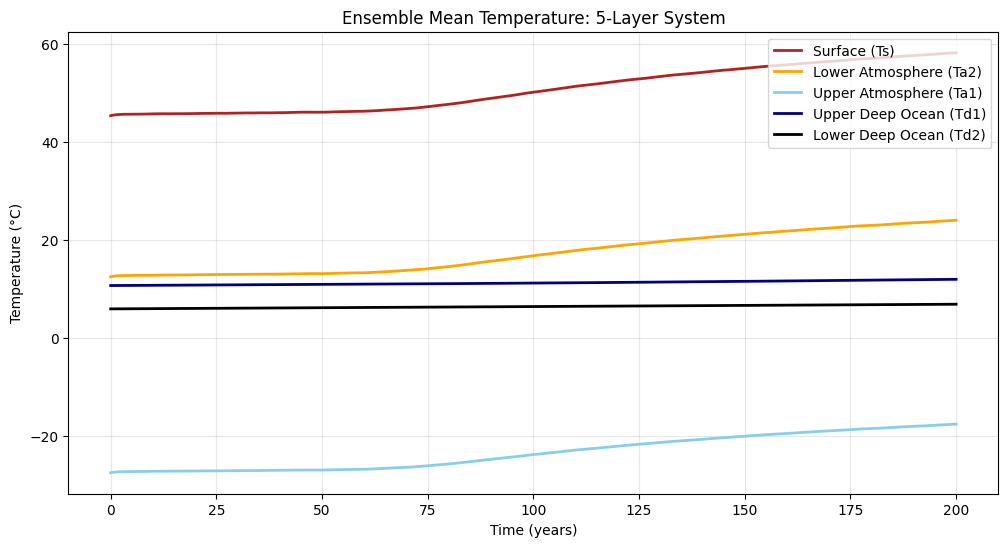

In [78]:
#--- MONTE CARLO DIAGNOSTIC PLOTS
# This cell generates a suite of visualizations to analyze the
# ensemble results, quantify uncertainty growth, and rank
# parameter sensitivity.

from scipy.stats import spearmanr

#--- Setup & Statistical Processing

# Extract final temperatures for distribution analysis
Ts_final = Ts_ensemble_C[:, -1]
# Calculate the running standard deviation (spread) across the ensemble
Ts_std = np.std(Ts_ensemble_C, axis=0)

# Calculate temperature anomalies relative to the start of each simulation
# This isolates the forced response from the absolute climatological spread
Ts_anom = Ts_ensemble_C - Ts_ensemble_C[:, [0]]
Ts_anom_mean = np.mean(Ts_anom, axis=0)

# Calculate percentiles for shaded uncertainty envelopes
Ts_anom_p05 = np.percentile(Ts_anom, 5, axis=0)   # Lower 5% tail
Ts_anom_p25 = np.percentile(Ts_anom, 25, axis=0)  # Lower quartile
Ts_anom_p50 = np.percentile(Ts_anom, 50, axis=0)  # Median
Ts_anom_p75 = np.percentile(Ts_anom, 75, axis=0)  # Upper quartile
Ts_anom_p95 = np.percentile(Ts_anom, 95, axis=0)  # Upper 95% tail

#--- 1. Ensemble Mean + Uncertainty Envelope
# WHY: This is the 'Executive Summary' plot. It shows the central expected
# outcome (mean) and the statistical confidence intervals. The shading
# helps distinguish between highly likely outcomes (darker) and tail risks (lighter).
plt.figure(figsize=(12, 6))
plt.fill_between(time, Ts_p05, Ts_p95, alpha=0.25, label='5-95% range')
plt.fill_between(time, Ts_p25, Ts_p75, alpha=0.40, label='25-75% range')
plt.plot(time, Ts_mean, color='black', lw=2, label='Ensemble mean')
plt.xlabel('Time (years)')
plt.ylabel('Surface temperature (°C)')
plt.title('Monte Carlo Ensemble: Surface Temperature')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#---2. Surface Temperature Anomaly
# WHY: Anomalies show the warming signal relative to the start of the simulation,
# effectively removing differences in the initial climatology between members.
# This isolates the forced 'warming' signal from the absolute background state.
plt.figure(figsize=(12, 6))
plt.fill_between(time, Ts_anom_p05, Ts_anom_p95, color='firebrick', alpha=0.15, label='5-95% range')
plt.fill_between(time, Ts_anom_p25, Ts_anom_p75, color='firebrick', alpha=0.30, label='25-75% range')
plt.plot(time, Ts_anom_mean, color='darkred', lw=2.5, label='Mean Anomaly')
plt.axhline(0, color='black', ls='--', lw=1)
plt.xlabel('Time (years)')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Monte Carlo Ensemble: Surface Temperature Anomaly (ΔTs)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#--- 3. Spaghetti Plot
# WHY: While the mean shows the trend, spaghetti plots show the individual
# 'realizations'. This illustrates the role of internal stochastic noise
# (weather) and ensures that the mean isn't hiding wild, non-physical oscillations.
plt.figure(figsize=(12, 6))
n_spaghetti = min(50, Ts_ensemble_C.shape[0])
idx = np.random.choice(Ts_ensemble_C.shape[0], n_spaghetti, replace=False)
for i in idx:
    plt.plot(time, Ts_ensemble_C[i], alpha=0.18, lw=0.8)
plt.plot(time, Ts_mean, color='black', lw=2.5, label='Ensemble mean')
plt.xlabel('Time (years)')
plt.ylabel('Surface temperature (°C)')
plt.title('Spaghetti Plot of Ensemble Members')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#--- 4. Final Temperature Distribution
# WHY: This histogram allows us to see the 'shape' of our uncertainty.
# If it's bimodal (two humps), it suggests the model might be flipping
# between stable states (e.g., Ice-Free vs. Snowball Earth).
plt.figure(figsize=(10, 5))
plt.hist(Ts_final, bins=30, alpha=0.75, edgecolor='black')
plt.axvline(np.mean(Ts_final), color='black', lw=2, label='Mean')
plt.axvline(np.percentile(Ts_final, 5), color='gray', ls='--', label='5-95% range')
plt.axvline(np.percentile(Ts_final, 95), color='gray', ls='--')
plt.xlabel('Final surface temperature (°C)')
plt.ylabel('Frequency')
plt.title('Distribution of Final Surface Temperature')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#--- 5. Probability of Exceedance
# WHY: In climate policy, we care about specific limits (e.g., 1.5°C or 2°C).
# This plot translates raw model data into risk probabilities, showing
# when the ensemble crosses critical warming thresholds.
thresholds = [1.5, 2.0, 3.0, 4.0]
plt.figure(figsize=(12, 6))
for threshold in thresholds:
    exceedance_prob = np.mean(Ts_anom > threshold, axis=0)
    plt.plot(time, exceedance_prob, lw=2, label=f'P(ΔT > {threshold}°C)')
plt.xlabel('Time (years)')
plt.ylabel('Probability')
plt.title('Probability of Exceeding Warming Thresholds')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#--- 6. Parameter Sensitivity Plot
# WHY: This tells us which input parameters 'matter' most. A high Spearman
# correlation means that parameter is a primary driver of warming. This
# guides future research by identifying which variables need more precision.
if "params_used" in globals():
    param_names = ["epsilon", "gamma1", "gamma2", "alpha_min", "alpha_max", "T_ice", "delta_T", "Cs", "Ca1", "Ca2", "Cd1", "Cd2", "A11", "A22"]
    sensitivity_names, sensitivity_values = [], []
    for name in param_names:
        try:
            values = np.array([p[name] for p in params_used])
            r, _ = spearmanr(values, Ts_final)
            if np.isfinite(r):
                sensitivity_names.append(name)
                sensitivity_values.append(r)
        except: pass
    sensitivity_values = np.array(sensitivity_values)
    order = np.argsort(np.abs(sensitivity_values))
    plt.figure(figsize=(10, 6))
    plt.barh(np.array(sensitivity_names)[order], sensitivity_values[order])
    plt.axvline(0, color='black', lw=1)
    plt.xlabel('Spearman correlation with final temperature')
    plt.title('Parameter Sensitivity Ranking')
    plt.grid(True, axis='x', alpha=0.3)
    plt.show()

#--- 7. Ensemble Uncertainty Growth
# WHY: Does the model spread stay narrow or explode over time?
# Rising standard deviation indicates that initial uncertainties or
# feedbacks are causing the ensemble members to diverge rapidly.
plt.figure(figsize=(12, 6))
plt.plot(time, Ts_std, color='black', lw=2)
plt.xlabel('Time (years)')
plt.ylabel('Ensemble standard deviation (°C)')
plt.title('Growth of Ensemble Uncertainty Over Time')
plt.grid(True, alpha=0.3)
plt.show()

#--- 8. 5-Layer Temperature Trajectories
# WHY: This visualizes the vertical thermal coupling of the Earth system.
# It shows how quickly heat penetrates from the surface (Ts) through the
# atmosphere (Ta) and into the deep ocean (Td1, Td2).
plt.figure(figsize=(12, 6))
plt.plot(time, Ts_mean, label='Surface (Ts)', color='firebrick', lw=2)
plt.plot(time, Ta2_mean, label='Lower Atmosphere (Ta2)', color='orange', lw=2)
plt.plot(time, Ta1_mean, label='Upper Atmosphere (Ta1)', color='skyblue', lw=2)
plt.plot(time, Td1_mean, label='Upper Deep Ocean (Td1)', color='navy', lw=2)
plt.plot(time, Td2_mean, label='Lower Deep Ocean (Td2)', color='black', lw=2)
plt.xlabel('Time (years)')
plt.ylabel('Temperature (°C)')
plt.title('Ensemble Mean Temperature: 5-Layer System')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()